# ESG Risk Score Regression

This notebook develops the analysis progressively: data inspection, cleaning, preprocessing, model estimation, model comparison and interpretation. Run the cells from top to bottom. The calculations and parameters are unchanged from the original notebook.

## Project setup

Import the libraries and define the general notebook environment.

In [68]:
# ============================================================
# FULL PIPELINE VERSION - ESG Risk Score Regression
# Same workflow as manual notebook, but with Pipeline/ColumnTransformer
# to avoid preprocessing leakage inside CV folds
# ============================================================

import os
import inspect
import warnings
import operator
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from IPython.display import display, Markdown

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score




## Output folder

Create the folder used to save the figures generated later in the analysis.

In [69]:
# ============================================================
# 0. Output folder for LaTeX images
# ============================================================

os.makedirs("images", exist_ok=True)




## Reusable preprocessing components

Define the custom transformers and helper functions used by the modelling pipelines.

In [70]:
# ============================================================
# 1. Custom transformers
# ============================================================

class Log1pSelectedTransformer(BaseEstimator, TransformerMixin):
    """
    Applies np.log1p() only to selected numeric columns.
    Used inside Pipeline so the transformation is part of CV.
    """
    def __init__(self, feature_names=None, log_cols=None):
        self.feature_names = feature_names
        self.log_cols = log_cols

    def fit(self, X, y=None):
        self.feature_names_ = list(self.feature_names)
        self.log_cols_ = [col for col in self.log_cols if col in self.feature_names_]
        self.log_indices_ = [self.feature_names_.index(col) for col in self.log_cols_]
        return self

    def transform(self, X):
        X_out = np.array(X, dtype=float, copy=True)
        for idx in self.log_indices_:
            X_out[:, idx] = np.log1p(X_out[:, idx])
        return X_out

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_)


class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """
    Groups rare Sector categories and combines High/Severe controversy levels.
    Learned inside each CV fold.
    """
    def __init__(
        self,
        feature_names=None,
        sector_col="Sector",
        controversy_col="Controversy Level",
        min_count=5
    ):
        self.feature_names = feature_names
        self.sector_col = sector_col
        self.controversy_col = controversy_col
        self.min_count = min_count

    def _to_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        return pd.DataFrame(X, columns=self.feature_names_)

    def fit(self, X, y=None):
        self.feature_names_ = list(self.feature_names)
        X_df = self._to_dataframe(X)

        if self.sector_col in X_df.columns:
            sector_counts = X_df[self.sector_col].value_counts()
            self.sectors_to_keep_ = sector_counts[
                sector_counts >= self.min_count
            ].index.tolist()
        else:
            self.sectors_to_keep_ = []

        return self

    def transform(self, X):
        X_df = self._to_dataframe(X)

        if self.sector_col in X_df.columns:
            X_df[self.sector_col] = np.where(
                X_df[self.sector_col].isin(self.sectors_to_keep_),
                X_df[self.sector_col],
                "Other Sector"
            )

        if self.controversy_col in X_df.columns:
            X_df[self.controversy_col] = X_df[self.controversy_col].replace({
                "High Controversy Level": "High/Severe Controversy Level",
                "Severe Controversy Level": "High/Severe Controversy Level"
            })

        return X_df

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_)


def make_ohe(drop=None):
    """
    Compatibility for old/new scikit-learn versions.
    """
    try:
        return OneHotEncoder(
            drop=drop,
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        return OneHotEncoder(
            drop=drop,
            handle_unknown="ignore",
            sparse=False
        )


def clean_feature_names(feature_names):
    """
    Removes ColumnTransformer prefixes for readable plots.
    """
    clean = []
    for name in feature_names:
        name = str(name)
        if "__" in name:
            name = name.split("__", 1)[1]
        clean.append(name)
    return clean


DISPLAY_NAME_MAP = {
    "Cash, Cash Equivalents & Short Term Investments": "Cash & ST Investments",
    "Change in Fixed Assets & Intangibles": "Change in Fixed Assets & Intangibles",
    "Operating Income (Loss)": "Operating Income",
    "Full Time Employees": "Employees",
    "Net Cash from Operating Activities": "Operating Cash Flow"
}


def pretty_feature_name(name):
    name = str(name)
    for original, short in DISPLAY_NAME_MAP.items():
        name = name.replace(original, short)
    return name


def pretty_feature_names(names):
    return [pretty_feature_name(name) for name in names]




## Load the dataset

Load the merged ESG and financial dataset, then inspect its initial structure.

In [71]:
# ============================================================
# 2. Load dataset
# ============================================================

df = pd.read_csv("esg_financials_merged_simfin_2023.csv")

print("Initial dataset shape:")
print(df.shape)

display(df.head())




Initial dataset shape:
(441, 26)


,Symbol,Name,Address,Sector,Industry,Full Time Employees,Description,Total ESG Risk score,Environment Risk Score,Governance Risk Score,...,Revenue,Operating Income (Loss),Net Income,"Cash, Cash Equivalents & Short Term Investments",Total Assets,Total Liabilities,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Financial_Statement_Type,Financial_Fiscal_Year
0,ENPH,"Enphase Energy, Inc.","47281 Bayside Parkway\nFremont, CA 94538\nUnit...",Technology,Solar,"3,157","Enphase Energy, Inc., together with its subsid...",NaN,NaN,NaN,...,2.290786e+09,4.614250e+08,438936000,1.695034e+09,3383012000,2.399388e+09,6.967800e+08,-110401000.0,corporate,2023
1,EMN,Eastman Chemical Company,"200 South Wilcox Drive\nKingsport, TN 37662\nU...",Basic Materials,Specialty Chemicals,"14,000",Eastman Chemical Company operates as a special...,25.3,12.8,6.6,...,9.210000e+09,1.054000e+09,894000000,5.480000e+08,14633000000,9.103000e+09,1.220000e+09,-828000000.0,corporate,2023
2,DPZ,Domino's Pizza Inc.,"30 Frank Lloyd Wright Drive\nAnn Arbor, MI 481...",Consumer Cyclical,Restaurants,"6,500","Domino's Pizza, Inc., through its subsidiaries...",29.2,10.6,6.3,...,4.479358e+09,8.196680e+08,519118000,1.140980e+08,1674899000,5.745266e+09,5.908640e+08,-105235000.0,corporate,2023
3,DVA,Davita Inc.,"2000 16th Street\nDenver, CO 80202\nUnited States",Healthcare,Medical Care Facilities,"70,000",DaVita Inc. provides kidney dialysis services ...,22.6,0.1,8.4,...,1.214015e+10,1.601003e+09,691535000,3.916730e+08,16893578000,1.415023e+10,2.059031e+09,-567985000.0,corporate,2023
4,DRI,"Darden Restaurants, Inc.","1000 Darden Center Drive\nOrlando, FL 32837\nU...",Consumer Cyclical,Restaurants,"187,384","Darden Restaurants, Inc., together with its su...",27.5,7.9,4.6,...,1.048780e+10,1.191200e+09,981900000,3.678000e+08,10241500000,8.040000e+09,1.552800e+09,-539500000.0,corporate,2023


## Missing-value overview

Check where missing observations are concentrated before cleaning the target and predictors.

In [72]:
# ============================================================
# 3. Missing values overview
# ============================================================

missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values(by="missing_count", ascending=False)

print("\nMissing values per column:")
display(missing_table)





Missing values per column:


,missing_count,missing_percent
Controversy Score,88,19.954649
ESG Risk Percentile,63,14.285714
Total ESG Risk score,63,14.285714
ESG Risk Level,63,14.285714
Controversy Level,63,14.285714
Social Risk Score,63,14.285714
Governance Risk Score,63,14.285714
Environment Risk Score,63,14.285714
Change in Fixed Assets & Intangibles,16,3.628118
Full Time Employees,4,0.907029


## Target cleaning

Remove rows without the ESG risk-score target and inspect the remaining target distribution.

In [73]:
# ============================================================
# 4. Target cleaning
# ============================================================

target = "Total ESG Risk score"

df_clean = df.dropna(subset=[target]).copy()
df_clean = df_clean.reset_index(drop=True)

print("\nShape after removing missing target:")
print(df_clean.shape)

print("\nTarget distribution:")
display(df_clean[target].describe())





Shape after removing missing target:
(378, 26)

Target distribution:


count    378.000000
mean      21.414286
std        6.825596
min        7.100000
25%       16.400000
50%       20.950000
75%       25.850000
max       41.700000
Name: Total ESG Risk score, dtype: float64

## Feature selection and leakage control

Remove identifiers, technical fields and variables that would leak information about the target.

In [74]:
# ============================================================
# 5. Feature selection and leakage prevention
# ============================================================

cols_to_remove = [
    "Symbol",
    "Name",
    "Address",
    "Description",
    "SimFinId",
    "Financial_Statement_Type",
    "Financial_Fiscal_Year",
    target
]

leakage_cols = [
    "Environment Risk Score",
    "Governance Risk Score",
    "Social Risk Score",
    "ESG Risk Percentile",
    "ESG Risk Level"
]

extra_cols_to_remove = [
    # Removed because it has high cardinality relative to the sample size
    "Industry",

    # Removed because it is the categorical counterpart of Controversy Score
    # and would duplicate the same controversy-related information.
    "Controversy Level"
]

cols_to_drop = [
    col for col in cols_to_remove + leakage_cols + extra_cols_to_remove
    if col in df_clean.columns
]

y = df_clean[target].copy()
X = df_clean.drop(columns=cols_to_drop).copy()

print("\nColumns removed from X:")
print(cols_to_drop)

print("\nShape X:", X.shape)
print("Shape y:", y.shape)

print("\nColumns remaining in X:")
print(X.columns.tolist())





Columns removed from X:
['Symbol', 'Name', 'Address', 'Description', 'SimFinId', 'Financial_Statement_Type', 'Financial_Fiscal_Year', 'Total ESG Risk score', 'Environment Risk Score', 'Governance Risk Score', 'Social Risk Score', 'ESG Risk Percentile', 'ESG Risk Level', 'Industry', 'Controversy Level']

Shape X: (378, 11)
Shape y: (378,)

Columns remaining in X:
['Sector', 'Full Time Employees', 'Controversy Score', 'Revenue', 'Operating Income (Loss)', 'Net Income', 'Cash, Cash Equivalents & Short Term Investments', 'Total Assets', 'Total Liabilities', 'Net Cash from Operating Activities', 'Change in Fixed Assets & Intangibles']


## Numeric conversion

Convert the financial variables to numeric format and check any missing values introduced by coercion.

In [75]:
# ============================================================
# 6. Force numeric columns to numeric format
# ============================================================

numeric_candidate_cols = [
    "Full Time Employees",
    "Controversy Score",
    "Revenue",
    "Operating Income (Loss)",
    "Net Income",
    "Cash, Cash Equivalents & Short Term Investments",
    "Total Assets",
    "Total Liabilities",
    "Net Cash from Operating Activities",
    "Change in Fixed Assets & Intangibles"
]

numeric_candidate_cols = [
    col for col in numeric_candidate_cols
    if col in X.columns
]

for col in numeric_candidate_cols:
    X[col] = (
        X[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    X[col] = pd.to_numeric(X[col], errors="coerce")

print("\nDtypes after numeric conversion:")
display(X.dtypes)

print("\nMissing values in X after numeric conversion:")
display(X.isna().sum().sort_values(ascending=False))





Dtypes after numeric conversion:


Sector                                              object
Full Time Employees                                float64
Controversy Score                                  float64
Revenue                                            float64
Operating Income (Loss)                            float64
Net Income                                           int64
Cash, Cash Equivalents & Short Term Investments    float64
Total Assets                                         int64
Total Liabilities                                  float64
Net Cash from Operating Activities                 float64
Change in Fixed Assets & Intangibles               float64
dtype: object


Missing values in X after numeric conversion:


Controversy Score                                  25
Change in Fixed Assets & Intangibles               14
Full Time Employees                                 4
Cash, Cash Equivalents & Short Term Investments     2
Net Cash from Operating Activities                  1
Sector                                              0
Revenue                                             0
Operating Income (Loss)                             0
Net Income                                          0
Total Assets                                        0
Total Liabilities                                   0
dtype: int64

## Train-test split

Create the fixed training and test samples used throughout the notebook.

In [76]:
# ============================================================
# 7. Train/test split
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("\nShape X_train_raw:", X_train_raw.shape)
print("Shape X_test_raw:", X_test_raw.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)

print("\nTarget distribution in training set:")
display(y_train.describe())

print("\nTarget distribution in test set:")
display(y_test.describe())





Shape X_train_raw: (302, 11)
Shape X_test_raw: (76, 11)
Shape y_train: (302,)
Shape y_test: (76,)

Target distribution in training set:


count    302.000000
mean      21.264901
std        6.835599
min        7.100000
25%       16.300000
50%       20.900000
75%       25.575000
max       41.700000
Name: Total ESG Risk score, dtype: float64


Target distribution in test set:


count    76.000000
mean     22.007895
std       6.798132
min      11.600000
25%      16.675000
50%      21.350000
75%      26.400000
max      38.700000
Name: Total ESG Risk score, dtype: float64

## Preliminary training diagnostics

Inspect numerical and categorical variables using training data only.

In [77]:
# ============================================================
# 8. Preliminary train-only preprocessing diagnostics
#    This is for explanation/plots only.
#    Model preprocessing will be inside Pipeline.
# ============================================================

X_train_diag = X_train_raw.copy()
X_test_diag = X_test_raw.copy()

# Remove Industry due to high cardinality
if "Industry" in X_train_diag.columns:
    X_train_diag = X_train_diag.drop(columns=["Industry"])
    X_test_diag = X_test_diag.drop(columns=["Industry"])

numeric_cols_initial = X_train_diag.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_initial = X_train_diag.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nInitial numeric variables:")
print(numeric_cols_initial)

print("\nInitial categorical variables:")
print(categorical_cols_initial)

# Numeric summary on training only
numeric_summary = pd.DataFrame({
    "missing_train": X_train_diag[numeric_cols_initial].isna().sum(),
    "min_train": X_train_diag[numeric_cols_initial].min(),
    "max_train": X_train_diag[numeric_cols_initial].max(),
    "mean_train": X_train_diag[numeric_cols_initial].mean(),
    "median_train": X_train_diag[numeric_cols_initial].median(),
    "skew_train": X_train_diag[numeric_cols_initial].skew()
}).sort_values(by="skew_train", ascending=False)

print("\nNumeric summary on training set:")
display(numeric_summary)

# Categorical summary
cat_summary = pd.DataFrame({
    "n_unique_train": X_train_diag[categorical_cols_initial].nunique(),
    "missing_train": X_train_diag[categorical_cols_initial].isna().sum()
})

print("\nCategorical cardinality on training set:")
display(cat_summary)

for col in categorical_cols_initial:
    print(f"\nFrequencies for {col} in training set:")
    display(X_train_diag[col].value_counts(dropna=False).head(20))





Initial numeric variables:
['Full Time Employees', 'Controversy Score', 'Revenue', 'Operating Income (Loss)', 'Net Income', 'Cash, Cash Equivalents & Short Term Investments', 'Total Assets', 'Total Liabilities', 'Net Cash from Operating Activities', 'Change in Fixed Assets & Intangibles']

Initial categorical variables:
['Sector']

Numeric summary on training set:


,missing_train,min_train,max_train,mean_train,median_train,skew_train
"Cash, Cash Equivalents & Short Term Investments",0,2.922000e+06,3.330730e+11,6.736438e+09,1.482600e+09,9.850107
Total Liabilities,0,1.712870e+08,2.680978e+12,6.031475e+10,1.656665e+10,9.231026
Total Assets,0,1.674899e+09,3.180151e+12,7.999864e+10,2.791230e+10,9.172850
Full Time Employees,2,1.630000e+02,2.100000e+06,6.883188e+04,2.300000e+04,8.249291
Net Income,0,-1.440700e+10,9.699500e+10,3.498559e+09,1.552095e+09,7.032866
Operating Income (Loss),0,-1.072500e+10,1.143010e+11,4.774399e+09,2.237000e+09,6.709757
Revenue,0,1.132154e+09,6.481250e+11,3.435183e+10,1.232227e+10,5.269651
Net Cash from Operating Activities,1,-7.341700e+10,1.105430e+11,5.365830e+09,2.330000e+09,3.542778
Controversy Score,20,1.000000e+00,5.000000e+00,2.000000e+00,2.000000e+00,0.511710
Change in Fixed Assets & Intangibles,11,-4.813300e+10,2.619778e+09,-1.935517e+09,-4.875760e+08,-5.689376



Categorical cardinality on training set:


,n_unique_train,missing_train
Sector,11,0



Frequencies for Sector in training set:


Sector
Technology                50
Consumer Cyclical         43
Industrials               39
Healthcare                38
Financial Services        33
Consumer Defensive        27
Utilities                 19
Real Estate               16
Basic Materials           15
Energy                    13
Communication Services     9
Name: count, dtype: int64

## Diagnostic preprocessing

Group rare categories, impute missing values and identify variables suitable for a log transformation.

In [78]:
# ============================================================
# 9. Diagnostic grouping, imputation and log-transform
#    Used only for displaying preprocessing outputs and correlation matrix.
# ============================================================

X_train_diag_grouped = X_train_diag.copy()
X_test_diag_grouped = X_test_diag.copy()

# Group rare sectors using training set
if "Sector" in X_train_diag_grouped.columns:
    sector_counts = X_train_diag_grouped["Sector"].value_counts()
    sectors_to_keep = sector_counts[sector_counts >= 5].index

    X_train_diag_grouped["Sector"] = np.where(
        X_train_diag_grouped["Sector"].isin(sectors_to_keep),
        X_train_diag_grouped["Sector"],
        "Other Sector"
    )

    X_test_diag_grouped["Sector"] = np.where(
        X_test_diag_grouped["Sector"].isin(sectors_to_keep),
        X_test_diag_grouped["Sector"],
        "Other Sector"
    )

# Group High/Severe controversy levels
if "Controversy Level" in X_train_diag_grouped.columns:
    X_train_diag_grouped["Controversy Level"] = X_train_diag_grouped["Controversy Level"].replace({
        "High Controversy Level": "High/Severe Controversy Level",
        "Severe Controversy Level": "High/Severe Controversy Level"
    })

    X_test_diag_grouped["Controversy Level"] = X_test_diag_grouped["Controversy Level"].replace({
        "High Controversy Level": "High/Severe Controversy Level",
        "Severe Controversy Level": "High/Severe Controversy Level"
    })

categorical_cols_diag = X_train_diag_grouped.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols_diag = X_train_diag_grouped.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical cardinality after rare-category grouping:")
display(pd.DataFrame({
    "n_unique_train": X_train_diag_grouped[categorical_cols_diag].nunique(),
    "n_unique_test": X_test_diag_grouped[categorical_cols_diag].nunique()
}))

# Diagnostic imputation using training only
X_train_diag_imp = X_train_diag_grouped.copy()
X_test_diag_imp = X_test_diag_grouped.copy()

numeric_medians_diag = X_train_diag_imp[numeric_cols_diag].median()
categorical_modes_diag = X_train_diag_imp[categorical_cols_diag].mode().iloc[0]

X_train_diag_imp[numeric_cols_diag] = X_train_diag_imp[numeric_cols_diag].fillna(numeric_medians_diag)
X_test_diag_imp[numeric_cols_diag] = X_test_diag_imp[numeric_cols_diag].fillna(numeric_medians_diag)

X_train_diag_imp[categorical_cols_diag] = X_train_diag_imp[categorical_cols_diag].fillna(categorical_modes_diag)
X_test_diag_imp[categorical_cols_diag] = X_test_diag_imp[categorical_cols_diag].fillna(categorical_modes_diag)

print("\nNumeric medians used in diagnostic preprocessing:")
display(numeric_medians_diag)

print("\nCategorical modes used in diagnostic preprocessing:")
display(categorical_modes_diag)

print("\nMissing values after diagnostic imputation - training:")
display(X_train_diag_imp.isna().sum().sort_values(ascending=False))

print("\nMissing values after diagnostic imputation - test:")
display(X_test_diag_imp.isna().sum().sort_values(ascending=False))


# Log-transform selected variables, same logic as manual notebook
candidate_log_cols = [
    "Full Time Employees",
    "Revenue",
    "Cash, Cash Equivalents & Short Term Investments",
    "Total Assets",
    "Total Liabilities"
]

log_cols = [
    col for col in candidate_log_cols
    if col in X_train_diag_imp.columns and (X_train_diag_imp[col] >= 0).all()
]

print("\nVariables selected for log-transform:")
print(log_cols)

print("\nMinimum values before log-transform:")
display(X_train_diag_imp[log_cols].min())

X_train_diag_fe = X_train_diag_imp.copy()
X_test_diag_fe = X_test_diag_imp.copy()

for col in log_cols:
    X_train_diag_fe[col] = np.log1p(X_train_diag_fe[col])
    X_test_diag_fe[col] = np.log1p(X_test_diag_fe[col])

skew_comparison = pd.DataFrame({
    "skew_before": X_train_diag_imp[log_cols].skew(),
    "skew_after": X_train_diag_fe[log_cols].skew()
}).sort_values(by="skew_before", ascending=False)

print("\nSkewness before and after log-transform:")
display(skew_comparison)





Categorical cardinality after rare-category grouping:


,n_unique_train,n_unique_test
Sector,11,11



Numeric medians used in diagnostic preprocessing:


Full Time Employees                                2.300000e+04
Controversy Score                                  2.000000e+00
Revenue                                            1.232227e+10
Operating Income (Loss)                            2.237000e+09
Net Income                                         1.552095e+09
Cash, Cash Equivalents & Short Term Investments    1.482600e+09
Total Assets                                       2.791230e+10
Total Liabilities                                  1.656665e+10
Net Cash from Operating Activities                 2.330000e+09
Change in Fixed Assets & Intangibles              -4.875760e+08
dtype: float64


Categorical modes used in diagnostic preprocessing:


...

Sector                                             0
Full Time Employees                                0
Controversy Score                                  0
Revenue                                            0
Operating Income (Loss)                            0
Net Income                                         0
Cash, Cash Equivalents & Short Term Investments    0
Total Assets                                       0
Total Liabilities                                  0
Net Cash from Operating Activities                 0
Change in Fixed Assets & Intangibles               0
dtype: int64


Variables selected for log-transform:
['Full Time Employees', 'Revenue', 'Cash, Cash Equivalents & Short Term Investments', 'Total Assets', 'Total Liabilities']

Minimum values before log-transform:


Full Time Employees                                1.630000e+02
Revenue                                            1.132154e+09
Cash, Cash Equivalents & Short Term Investments    2.922000e+06
Total Assets                                       1.674899e+09
Total Liabilities                                  1.712870e+08
dtype: float64


Skewness before and after log-transform:


,skew_before,skew_after
"Cash, Cash Equivalents & Short Term Investments",9.850107,-0.106123
Total Liabilities,9.231026,0.374220
Total Assets,9.172850,0.626779
Full Time Employees,8.275771,-0.120506
Revenue,5.269651,0.687586


## Constants and correlations

Check constant predictors and study correlations among the transformed numerical variables.


Number of unique values per variable:


Controversy Score                                    5
Sector                                              11
Full Time Employees                                252
Change in Fixed Assets & Intangibles               289
Operating Income (Loss)                            298
Net Cash from Operating Activities                 300
Net Income                                         301
Cash, Cash Equivalents & Short Term Investments    301
Total Liabilities                                  301
Revenue                                            302
Total Assets                                       302
dtype: int64


Constant variables:
[]

Correlation matrix among numeric variables:


,Full Time Employees,Controversy Score,Revenue,Operating Income (Loss),Net Income,"Cash, Cash Equivalents & Short Term Investments",Total Assets,Total Liabilities,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles
Full Time Employees,1.000000,0.468728,0.747534,0.326781,0.313672,0.466074,0.478308,0.497216,0.319388,-0.323787
Controversy Score,0.468728,1.000000,0.558038,0.321037,0.312690,0.380223,0.483313,0.503604,0.289926,-0.325186
Revenue,0.747534,0.558038,1.000000,0.570952,0.538492,0.598968,0.728514,0.698664,0.534131,-0.495383
Operating Income (Loss),0.326781,0.321037,0.570952,1.000000,0.954862,0.456367,0.499699,0.456497,0.817805,-0.539007
Net Income,0.313672,0.312690,0.538492,0.954862,1.000000,0.465641,0.467425,0.420421,0.812439,-0.487103
"Cash, Cash Equivalents & Short Term Investments",0.466074,0.380223,0.598968,0.456367,0.465641,1.000000,0.578295,0.488608,0.411509,-0.313120
Total Assets,0.478308,0.483313,0.728514,0.499699,0.467425,0.578295,1.000000,0.937914,0.408145,-0.450133
Total Liabilities,0.497216,0.503604,0.698664,0.456497,0.420421,0.488608,0.937914,1.000000,0.362507,-0.389879
Net Cash from Operating Activities,0.319388,0.289926,0.534131,0.817805,0.812439,0.411509,0.408145,0.362507,1.000000,-0.640122
Change in Fixed Assets & Intangibles,-0.323787,-0.325186,-0.495383,-0.539007,-0.487103,-0.313120,-0.450133,-0.389879,-0.640122,1.000000



Pairs with absolute correlation greater than 0.80:


,Variable_1,Variable_2,Abs_Correlation
24,Operating Income (Loss),Net Income,0.954862
39,Total Assets,Total Liabilities,0.937914
28,Operating Income (Loss),Net Cash from Operating Activities,0.817805
33,Net Income,Net Cash from Operating Activities,0.812439


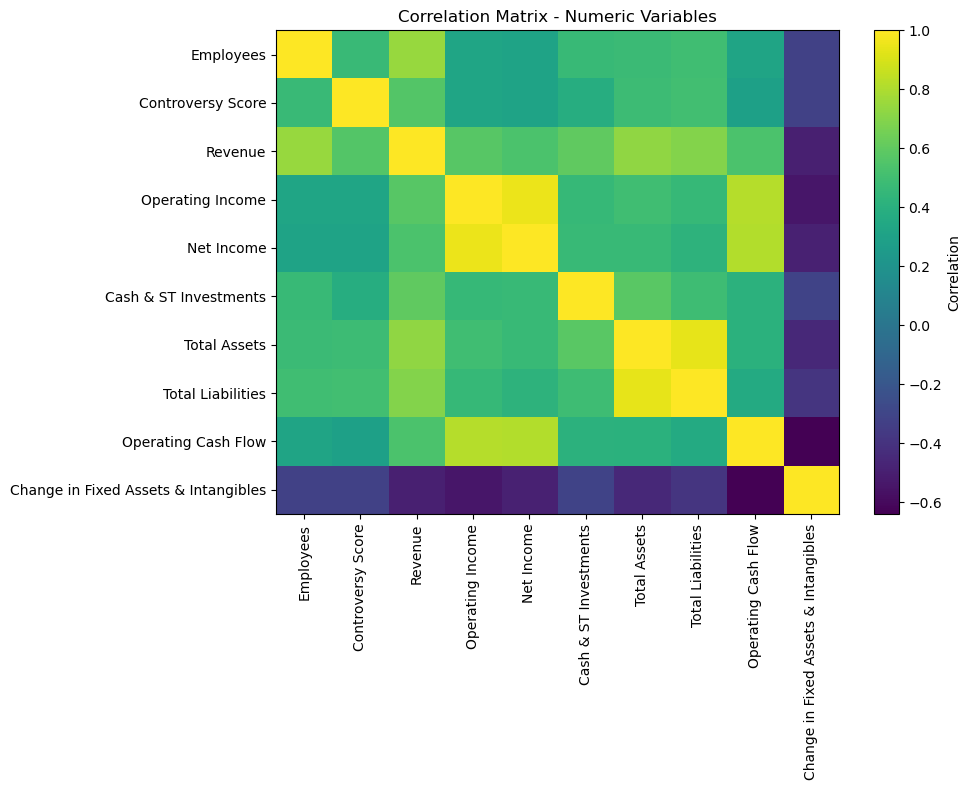


Saved image: images/correlation_matrix.png


In [79]:
# ============================================================
# 10. Constant variables and correlation matrix
# ============================================================

unique_counts = X_train_diag_fe.nunique().sort_values()

print("\nNumber of unique values per variable:")
display(unique_counts)

constant_cols = unique_counts[unique_counts <= 1].index.tolist()

print("\nConstant variables:")
print(constant_cols)

# Drop constants in diagnostic data
X_train_diag_fe = X_train_diag_fe.drop(columns=constant_cols)
X_test_diag_fe = X_test_diag_fe.drop(columns=constant_cols)

numeric_cols_diag = X_train_diag_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_diag = X_train_diag_fe.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

corr_matrix = X_train_diag_fe[numeric_cols_diag].corr()

print("\nCorrelation matrix among numeric variables:")
display(corr_matrix)

corr_abs = corr_matrix.abs()

high_corr_pairs = (
    corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["Variable_1", "Variable_2", "Abs_Correlation"]
high_corr_pairs = high_corr_pairs.sort_values(by="Abs_Correlation", ascending=False)

print("\nPairs with absolute correlation greater than 0.80:")
display(high_corr_pairs[high_corr_pairs["Abs_Correlation"] > 0.80])

# Correlation heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
corr_plot_labels = pretty_feature_names(corr_matrix.columns)
plt.xticks(range(len(corr_matrix.columns)), corr_plot_labels, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_plot_labels)
plt.title("Correlation Matrix - Numeric Variables")
plt.tight_layout()
plt.savefig("images/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved image: images/correlation_matrix.png")




## Multicollinearity reduction

Remove highly correlated predictors before building the final modelling datasets.

In [80]:
# ============================================================
# 11. Drop highly correlated variables
# ============================================================

# The new SimFin financial variables contain highly correlated blocks.
# To keep coefficient interpretation cleaner, we remove the minimum set
# of variables needed to break the main |correlation| > 0.80 pairs.
#
# Kept: Operating Income (Loss), Total Assets
# Removed: Net Income, Net Cash from Operating Activities, Total Liabilities
high_corr_to_drop = [
    "Net Income",
    "Net Cash from Operating Activities",
    "Total Liabilities"
]

high_corr_to_drop = [
    col for col in high_corr_to_drop
    if col in X_train_diag_fe.columns
]

print("\nVariables removed for high multicollinearity:")
print(high_corr_to_drop)

# Final raw datasets for model pipelines
X_train_model = X_train_raw.copy()
X_test_model = X_test_raw.copy()

# Remove Industry
if "Industry" in X_train_model.columns:
    X_train_model = X_train_model.drop(columns=["Industry"])
    X_test_model = X_test_model.drop(columns=["Industry"])

# Remove constant columns if any
X_train_model = X_train_model.drop(columns=[col for col in constant_cols if col in X_train_model.columns])
X_test_model = X_test_model.drop(columns=[col for col in constant_cols if col in X_test_model.columns])

# Remove high-correlation columns
X_train_model = X_train_model.drop(columns=[col for col in high_corr_to_drop if col in X_train_model.columns])
X_test_model = X_test_model.drop(columns=[col for col in high_corr_to_drop if col in X_test_model.columns])

numeric_features = X_train_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train_model.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nFinal X_train_model shape:", X_train_model.shape)
print("Final X_test_model shape:", X_test_model.shape)

print("\nFinal numeric features:")
print(numeric_features)

print("\nFinal categorical features:")
print(categorical_features)

# Log-transform variables actually used by the model pipelines
model_log_cols = [
    col for col in log_cols
    if col in numeric_features
]

print("\nLog-transformed variables actually used in model pipelines:")
print(model_log_cols)

print("\nImportant preprocessing decisions:")
print("- Industry removed because of high cardinality.")
print("- Controversy Level removed because it is redundant with Controversy Score.")
print("- Net Income, Total Liabilities and Net Cash from Operating Activities removed for high multicollinearity.")
print("- Linear models use one-hot encoding with baseline category removed.")
print("- Tree-based models use full one-hot encoding and no scaling.")
print("- SVR and neural networks use full one-hot encoding and scaling.")





Variables removed for high multicollinearity:
['Net Income', 'Net Cash from Operating Activities', 'Total Liabilities']

Final X_train_model shape: (302, 8)
Final X_test_model shape: (76, 8)

Final numeric features:
['Full Time Employees', 'Controversy Score', 'Revenue', 'Operating Income (Loss)', 'Cash, Cash Equivalents & Short Term Investments', 'Total Assets', 'Change in Fixed Assets & Intangibles']

Final categorical features:
['Sector']

Log-transformed variables actually used in model pipelines:
['Full Time Employees', 'Revenue', 'Cash, Cash Equivalents & Short Term Investments', 'Total Assets']

Important preprocessing decisions:
- Industry removed because of high cardinality.
- Controversy Level removed because it is redundant with Controversy Score.
- Net Income, Total Liabilities and Net Cash from Operating Activities removed for high multicollinearity.
- Linear models use one-hot encoding with baseline category removed.
- Tree-based models use full one-hot encoding and no s

## Model preprocessors

Construct the preprocessing pipelines used by linear and nonlinear models.

In [81]:
# ============================================================
# 12. Preprocessors
# ============================================================

# Linear models:
# - numeric imputation
# - log-transform selected numeric variables
# - categorical imputation + rare grouping + one-hot with drop_first=True
# - StandardScaler on the full encoded matrix, to mimic manual X_train_lin
linear_column_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("log", Log1pSelectedTransformer(
                feature_names=numeric_features,
                log_cols=model_log_cols
            ))
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("rare", RareCategoryGrouper(
                feature_names=categorical_features,
                sector_col="Sector",
                controversy_col="Controversy Level",
                min_count=5
            )),
            ("onehot", make_ohe(drop="first"))
        ]), categorical_features)
    ],
    remainder="drop"
)

linear_preprocessor = Pipeline([
    ("columns", linear_column_preprocessor),
    ("scaler", StandardScaler())
])

# Tree-based models:
# - numeric imputation + log-transform
# - categorical imputation + rare grouping + full one-hot
# - no scaling
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("log", Log1pSelectedTransformer(
                feature_names=numeric_features,
                log_cols=model_log_cols
            ))
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("rare", RareCategoryGrouper(
                feature_names=categorical_features,
                sector_col="Sector",
                controversy_col="Controversy Level",
                min_count=5
            )),
            ("onehot", make_ohe(drop=None))
        ]), categorical_features)
    ],
    remainder="drop"
)




## Validation framework

Define cross-validation, evaluation metrics and the common model-evaluation function.

In [82]:
# ============================================================
# 13. CV and metrics
# ============================================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "mse": "neg_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2


results = []
fitted_models = {}
predictions = {}


def evaluate_fixed_model(model_name, pipeline, dataset_type, scaling, best_params):
    print("\n" + "="*70)
    print(model_name)
    print("="*70)

    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train_model,
        y=y_train,
        cv=kf,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    cv_mse_scores = -cv_results["test_mse"]
    cv_mae_scores = -cv_results["test_mae"]
    cv_r2_scores = cv_results["test_r2"]

    cv_mse = cv_mse_scores.mean()
    cv_rmse = np.sqrt(cv_mse_scores).mean()
    cv_mae = cv_mae_scores.mean()
    cv_r2 = cv_r2_scores.mean()

    pipeline.fit(X_train_model, y_train)
    y_pred = pipeline.predict(X_test_model)

    test_mse, test_rmse, test_mae, test_r2 = regression_metrics(y_test, y_pred)

    print("CV MSE:", cv_mse)
    print("CV RMSE:", cv_rmse)
    print("CV MAE:", cv_mae)
    print("CV R2:", cv_r2)

    print("\nTest MSE:", test_mse)
    print("Test RMSE:", test_rmse)
    print("Test MAE:", test_mae)
    print("Test R2:", test_r2)

    results.append({
        "Model": model_name,
        "Dataset_Type": dataset_type,
        "Scaling": scaling,
        "Best_Params": best_params,
        "CV_MSE": cv_mse,
        "Test_MSE": test_mse,
        "CV_RMSE": cv_rmse,
        "Test_RMSE": test_rmse,
        "CV_MAE": cv_mae,
        "Test_MAE": test_mae,
        "CV_R2": cv_r2,
        "Test_R2": test_r2
    })

    fitted_models[model_name] = pipeline
    predictions[model_name] = y_pred


def evaluate_grid_model(model_name, pipeline, param_grid, dataset_type, scaling):
    print("\n" + "="*70)
    print(model_name)
    print("="*70)

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=kf,
        n_jobs=-1
    )

    grid.fit(X_train_model, y_train)

    best_pipeline = grid.best_estimator_
    best_params = grid.best_params_

    print("Best params:")
    print(best_params)
    print("Best CV MSE from GridSearch:", -grid.best_score_)
    print("Best CV RMSE from GridSearch:", np.sqrt(-grid.best_score_))

    cv_results = cross_validate(
        estimator=best_pipeline,
        X=X_train_model,
        y=y_train,
        cv=kf,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    cv_mse_scores = -cv_results["test_mse"]
    cv_mae_scores = -cv_results["test_mae"]
    cv_r2_scores = cv_results["test_r2"]

    cv_mse = cv_mse_scores.mean()
    cv_rmse = np.sqrt(cv_mse_scores).mean()
    cv_mae = cv_mae_scores.mean()
    cv_r2 = cv_r2_scores.mean()

    best_pipeline.fit(X_train_model, y_train)
    y_pred = best_pipeline.predict(X_test_model)

    test_mse, test_rmse, test_mae, test_r2 = regression_metrics(y_test, y_pred)

    print("\nCV MSE:", cv_mse)
    print("CV RMSE:", cv_rmse)
    print("CV MAE:", cv_mae)
    print("CV R2:", cv_r2)

    print("\nTest MSE:", test_mse)
    print("Test RMSE:", test_rmse)
    print("Test MAE:", test_mae)
    print("Test R2:", test_r2)

    results.append({
        "Model": model_name,
        "Dataset_Type": dataset_type,
        "Scaling": scaling,
        "Best_Params": best_params,
        "CV_MSE": cv_mse,
        "Test_MSE": test_mse,
        "CV_RMSE": cv_rmse,
        "Test_RMSE": test_rmse,
        "CV_MAE": cv_mae,
        "Test_MAE": test_mae,
        "CV_R2": cv_r2,
        "Test_R2": test_r2
    })

    fitted_models[model_name] = best_pipeline
    predictions[model_name] = y_pred

    return best_pipeline, best_params




## Linear regression

Estimate the baseline linear model and evaluate it on cross-validation and test data.


Linear Regression
CV MSE: 26.707417980047246
CV RMSE: 5.163159140876752
CV MAE: 4.06792147873333
CV R2: 0.41002593246684144

Test MSE: 27.642893463640892
Test RMSE: 5.257650945397659
Test MAE: 4.403578831811106
Test R2: 0.393882815176103

Baseline categories dropped in linear-model one-hot encoding:
- Sector: Basic Materials

Linear Regression vs Mean Baseline:


,Model,Test_MSE,Test_RMSE,Test_MAE,Test_R2
0,Mean Baseline,46.158557,6.794009,5.642105,-0.012104
1,Linear Regression,27.642893,5.257651,4.403579,0.393883


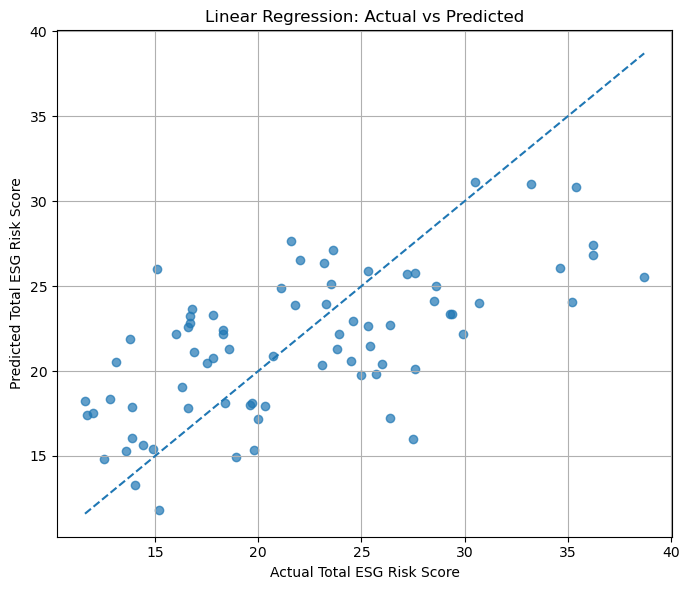


Saved image: images/linear_regression_actual_vs_predicted.png

Statsmodels OLS summary on transformed training data:
                             OLS Regression Results                             
Dep. Variable:     Total ESG Risk score   R-squared:                       0.491
Model:                              OLS   Adj. R-squared:                  0.460
Method:                   Least Squares   F-statistic:                     16.10
Date:                  Wed, 05 Aug 2026   Prob (F-statistic):           1.49e-32
Time:                          10:36:26   Log-Likelihood:                -906.59
No. Observations:                   302   AIC:                             1849.
Df Residuals:                       284   BIC:                             1916.
Df Model:                            17                                         
Covariance Type:              nonrobust                                         
                                                      coef    std err   

In [83]:
# ============================================================
# 14. Linear Regression
# ============================================================

linear_pipe = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", LinearRegression())
])

evaluate_fixed_model(
    model_name="Linear Regression",
    pipeline=linear_pipe,
    dataset_type="lin",
    scaling="Inside Pipeline",
    best_params="None"
)

# Print baseline categories dropped by one-hot encoding for the linear models
try:
    fitted_linear_columns = fitted_models["Linear Regression"].named_steps["preprocessor"].named_steps["columns"]
    fitted_cat_pipe = fitted_linear_columns.named_transformers_["cat"]
    fitted_ohe = fitted_cat_pipe.named_steps["onehot"]

    print("\nBaseline categories dropped in linear-model one-hot encoding:")
    for col, cats in zip(categorical_features, fitted_ohe.categories_):
        print(f"- {col}: {cats[0]}")
except Exception as e:
    print("\nCould not print dropped baseline categories.")
    print("Reason:", e)

# Baseline comparison
y_pred_mean_baseline = np.repeat(y_train.mean(), len(y_test))
baseline_mse, baseline_rmse, baseline_mae, baseline_r2 = regression_metrics(
    y_test,
    y_pred_mean_baseline
)

lin_pred = predictions["Linear Regression"]
lin_mse, lin_rmse, lin_mae, lin_r2 = regression_metrics(y_test, lin_pred)

baseline_comparison = pd.DataFrame({
    "Model": ["Mean Baseline", "Linear Regression"],
    "Test_MSE": [baseline_mse, lin_mse],
    "Test_RMSE": [baseline_rmse, lin_rmse],
    "Test_MAE": [baseline_mae, lin_mae],
    "Test_R2": [baseline_r2, lin_r2]
})

print("\nLinear Regression vs Mean Baseline:")
display(baseline_comparison)

# Actual vs Predicted plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, lin_pred, alpha=0.7)

min_value = min(y_test.min(), lin_pred.min())
max_value = max(y_test.max(), lin_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Total ESG Risk Score")
plt.ylabel("Predicted Total ESG Risk Score")
plt.grid(True)
plt.tight_layout()
plt.savefig("images/linear_regression_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved image: images/linear_regression_actual_vs_predicted.png")


# Optional statsmodels OLS summary on full transformed training set
try:
    import statsmodels.api as sm

    linear_fitted_preprocessor = fitted_models["Linear Regression"].named_steps["preprocessor"]
    X_train_ols_array = linear_fitted_preprocessor.transform(X_train_model)

    try:
        ols_feature_names = linear_fitted_preprocessor.named_steps["columns"].get_feature_names_out()
        ols_feature_names = clean_feature_names(ols_feature_names)
    except Exception:
        ols_feature_names = [f"x{i}" for i in range(X_train_ols_array.shape[1])]

    X_train_ols = pd.DataFrame(
        X_train_ols_array,
        columns=ols_feature_names,
        index=X_train_model.index
    )

    X_train_ols = sm.add_constant(X_train_ols)
    ols_results = sm.OLS(y_train.astype(float), X_train_ols.astype(float)).fit()

    print("\nStatsmodels OLS summary on transformed training data:")
    print(ols_results.summary())

except Exception as e:
    print("\nStatsmodels OLS summary skipped.")
    print("Reason:", e)




## Ridge regression

Tune and evaluate the Ridge model using the same validation framework.

In [84]:
# ============================================================
# 15. Ridge Regression
# ============================================================

ridge_pipe = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": np.logspace(-4, 4, 100)
}

evaluate_grid_model(
    model_name="Ridge Regression",
    pipeline=ridge_pipe,
    param_grid=ridge_param_grid,
    dataset_type="lin",
    scaling="Inside Pipeline"
)





Ridge Regression
Best params:
{'model__alpha': 3.351602650938848}
Best CV MSE from GridSearch: 26.644026617518943
Best CV RMSE from GridSearch: 5.161785216135881

CV MSE: 26.644026617518943
CV RMSE: 5.156337216323774
CV MAE: 4.074474736664478
CV R2: 0.41186607702772793

Test MSE: 27.84145542048682
Test RMSE: 5.276500300434638
Test MAE: 4.411653007256913
Test R2: 0.38952900849320715


(Pipeline(steps=[('preprocessor',
                  Pipeline(steps=[('columns',
                                   ColumnTransformer(transformers=[('num',
                                                                    Pipeline(steps=[('imputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('log',
                                                                                     Log1pSelectedTransformer(feature_names=['Full '
                                                                                                                             'Time '
                                                                                                                             'Employees',
                                                                                                                             'Controv

## Lasso regression

Tune and evaluate the Lasso model.

In [85]:
# ============================================================
# 16. Lasso Regression
# ============================================================

lasso_pipe = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Lasso(max_iter=10000, random_state=42))
])

lasso_param_grid = {
    "model__alpha": np.logspace(-4, 2, 100)
}

lasso_fitted, best_lasso_params = evaluate_grid_model(
    model_name="Lasso Regression",
    pipeline=lasso_pipe,
    param_grid=lasso_param_grid,
    dataset_type="lin",
    scaling="Inside Pipeline"
)

lasso_coef = lasso_fitted.named_steps["model"].coef_
n_total_coef_lasso = len(lasso_coef)
n_zero_coef_lasso = np.sum(lasso_coef == 0)
n_nonzero_coef_lasso = n_total_coef_lasso - n_zero_coef_lasso

print("\nLasso coefficient sparsity:")
print("Total coefficients:", n_total_coef_lasso)
print("Zero coefficients:", n_zero_coef_lasso)
print("Non-zero coefficients:", n_nonzero_coef_lasso)





Lasso Regression
Best params:
{'model__alpha': 0.040370172585965536}
Best CV MSE from GridSearch: 26.604895402178688
Best CV RMSE from GridSearch: 5.15799335034262

CV MSE: 26.604895402178688
CV RMSE: 5.151819729595508
CV MAE: 4.083377750195434
CV R2: 0.41274828223088356

Test MSE: 27.951104612935797
Test RMSE: 5.2868804235518505
Test MAE: 4.421903677977439
Test R2: 0.38712476452602607

Lasso coefficient sparsity:
Total coefficients: 17
Zero coefficients: 1
Non-zero coefficients: 16


## Polynomial regression

Compare second- and third-degree polynomial specifications.

In [86]:
# ============================================================
# 17. Polynomial Regression degree 2 and 3
# ============================================================

for degree in [2, 3]:

    poly_pipe = Pipeline([
        ("preprocessor", linear_preprocessor),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("model", LinearRegression())
    ])

    evaluate_fixed_model(
        model_name=f"Polynomial Regression degree {degree}",
        pipeline=poly_pipe,
        dataset_type="lin",
        scaling="Inside Pipeline",
        best_params={"degree": degree}
    )

    fitted_poly = fitted_models[f"Polynomial Regression degree {degree}"]
    poly_step = fitted_poly.named_steps["poly"]

    print(f"\nPolynomial Regression degree {degree}")
    print("Original number of features after preprocessing:",
          fitted_poly.named_steps["preprocessor"].transform(X_train_model.iloc[:1]).shape[1])
    print("Polynomial number of features:", poly_step.n_output_features_)





Polynomial Regression degree 2
CV MSE: 2.652386569389842e+24
CV RMSE: 777241792845.7559
CV MAE: 130464052037.43411
CV R2: -7.1269850673813956e+22

Test MSE: 884.4476585004968
Test RMSE: 29.739664734164318
Test MAE: 8.695369198447779
Test R2: -18.393010561630284

Polynomial Regression degree 2
Original number of features after preprocessing: 17
Polynomial number of features: 170

Polynomial Regression degree 3
CV MSE: 1935016.0670818922
CV RMSE: 851.793065483004
CV MAE: 195.40097431827462
CV R2: -37047.176077782795

Test MSE: 2763855.7605611146
Test RMSE: 1662.484815137003
Test MAE: 347.9133157559466
Test R2: -60601.21138044234

Polynomial Regression degree 3
Original number of features after preprocessing: 17
Polynomial number of features: 1139


## Generalized additive model

Fit and evaluate the GAM specification.

In [87]:
# ============================================================
# 18. GAM
# ============================================================

try:
    from pygam import LinearGAM, s, l

    print("\n" + "="*70)
    print("GAM")
    print("="*70)

    candidate_spline_features = [
        "Full Time Employees",
        "Revenue",
        "Operating Income (Loss)",
        "Cash, Cash Equivalents & Short Term Investments",
        "Total Assets",
        "Change in Fixed Assets & Intangibles",
        "Controversy Score"
    ]

    spline_features = [
        feature for feature in candidate_spline_features
        if feature in numeric_features
    ]

    spline_indices = [
        numeric_features.index(feature)
        for feature in spline_features
    ]

    print("Spline features:")
    print(spline_features)
    print("Number of spline terms:", len(spline_indices))

    def build_gam_terms(n_features, spline_indices):
        terms_list = []

        for idx in spline_indices:
            terms_list.append(s(idx, n_splines=5))

        linear_indices = [
            idx for idx in range(n_features)
            if idx not in spline_indices
        ]

        for idx in linear_indices:
            terms_list.append(l(idx))

        return reduce(operator.add, terms_list)

    gam_lams = np.logspace(-3, 3, 7)
    gam_cv_results_list = []

    for lam in gam_lams:

        fold_mse = []
        fold_mae = []
        fold_r2 = []

        for train_idx, val_idx in kf.split(X_train_model):

            X_fold_train = X_train_model.iloc[train_idx]
            X_fold_val = X_train_model.iloc[val_idx]
            y_fold_train = y_train.iloc[train_idx]
            y_fold_val = y_train.iloc[val_idx]

            fold_preprocessor = clone(linear_preprocessor)

            X_fold_train_trans = fold_preprocessor.fit_transform(X_fold_train)
            X_fold_val_trans = fold_preprocessor.transform(X_fold_val)

            gam_terms = build_gam_terms(
                n_features=X_fold_train_trans.shape[1],
                spline_indices=spline_indices
            )

            gam_model = LinearGAM(
                terms=gam_terms,
                lam=lam
            )

            gam_model.fit(X_fold_train_trans, y_fold_train.values)

            y_fold_pred = gam_model.predict(X_fold_val_trans)

            fold_mse.append(mean_squared_error(y_fold_val, y_fold_pred))
            fold_mae.append(mean_absolute_error(y_fold_val, y_fold_pred))
            fold_r2.append(r2_score(y_fold_val, y_fold_pred))

        gam_cv_results_list.append({
            "lambda": lam,
            "CV_MSE": np.mean(fold_mse),
            "CV_RMSE": np.mean(np.sqrt(fold_mse)),
            "CV_MAE": np.mean(fold_mae),
            "CV_R2": np.mean(fold_r2)
        })

    gam_cv_table = pd.DataFrame(gam_cv_results_list).sort_values(
        by="CV_MSE",
        ascending=True
    ).reset_index(drop=True)

    print("\nGAM lambda tuning table:")
    display(gam_cv_table)

    best_gam_lam = gam_cv_table.loc[0, "lambda"]

    print("Best lambda:", best_gam_lam)

    gam_preprocessor_final = clone(linear_preprocessor)

    X_train_gam = gam_preprocessor_final.fit_transform(X_train_model)
    X_test_gam = gam_preprocessor_final.transform(X_test_model)

    gam_final_terms = build_gam_terms(
        n_features=X_train_gam.shape[1],
        spline_indices=spline_indices
    )

    gam_final = LinearGAM(
        terms=gam_final_terms,
        lam=best_gam_lam
    )

    gam_final.fit(X_train_gam, y_train.values)

    y_pred_gam = gam_final.predict(X_test_gam)

    gam_test_mse, gam_test_rmse, gam_test_mae, gam_test_r2 = regression_metrics(
        y_test,
        y_pred_gam
    )

    best_gam_cv_row = gam_cv_table.loc[0]

    print("\nGAM Test Metrics")
    print("Test MSE:", gam_test_mse)
    print("Test RMSE:", gam_test_rmse)
    print("Test MAE:", gam_test_mae)
    print("Test R2:", gam_test_r2)

    results.append({
        "Model": "GAM",
        "Dataset_Type": "lin",
        "Scaling": "Inside Pipeline",
        "Best_Params": {"lambda": best_gam_lam},
        "CV_MSE": best_gam_cv_row["CV_MSE"],
        "Test_MSE": gam_test_mse,
        "CV_RMSE": best_gam_cv_row["CV_RMSE"],
        "Test_RMSE": gam_test_rmse,
        "CV_MAE": best_gam_cv_row["CV_MAE"],
        "Test_MAE": gam_test_mae,
        "CV_R2": best_gam_cv_row["CV_R2"],
        "Test_R2": gam_test_r2
    })

    fitted_models["GAM"] = gam_final
    predictions["GAM"] = y_pred_gam

except ImportError:
    print("\npygam is not installed. GAM skipped.")
    print("If using Colab, run: !pip install pygam")





GAM
Spline features:
['Full Time Employees', 'Revenue', 'Operating Income (Loss)', 'Cash, Cash Equivalents & Short Term Investments', 'Total Assets', 'Change in Fixed Assets & Intangibles', 'Controversy Score']
Number of spline terms: 7



GAM lambda tuning table:


,lambda,CV_MSE,CV_RMSE,CV_MAE,CV_R2
0,1.000,26.474076,5.138810,4.031798,0.415883
1,10.000,26.683817,5.159852,4.088595,0.411317
2,0.100,27.041186,5.192618,4.083932,0.403328
3,0.010,28.559201,5.339639,4.215822,0.368353
4,100.000,28.592118,5.341680,4.270299,0.369986
5,0.001,31.738166,5.620307,4.364212,0.304103
6,1000.000,36.227112,6.007582,4.824624,0.205679


Best lambda: 1.0

GAM Test Metrics
Test MSE: 26.233517897337105
Test RMSE: 5.121866641893081
Test MAE: 4.265686794766265
Test R2: 0.4247857577979107


## Decision tree

Use cost-complexity pruning to select and evaluate a regression tree.


Decision Tree Regression - cost-complexity pruning path
Number of candidate ccp_alpha values: 246
First alpha: 0.0
Last alpha: 3.4706733982679214

Decision Tree


Best params:
{'model__ccp_alpha': 2.1683775430874235}
Best CV MSE from GridSearch: 40.319687873796894
Best CV RMSE from GridSearch: 6.349778568879146

CV MSE: 40.319687873796894
CV RMSE: 6.338408854430881
CV MAE: 5.052167395450226
CV R2: 0.11720797422853409

Test MSE: 31.71197879612428
Test RMSE: 5.6313389878539795
Test MAE: 4.406909998456817
Test R2: 0.30466123821719826

Decision Tree complexity:
Best ccp_alpha: 2.1683775430874235
Tree depth: 3
Number of leaves: 4


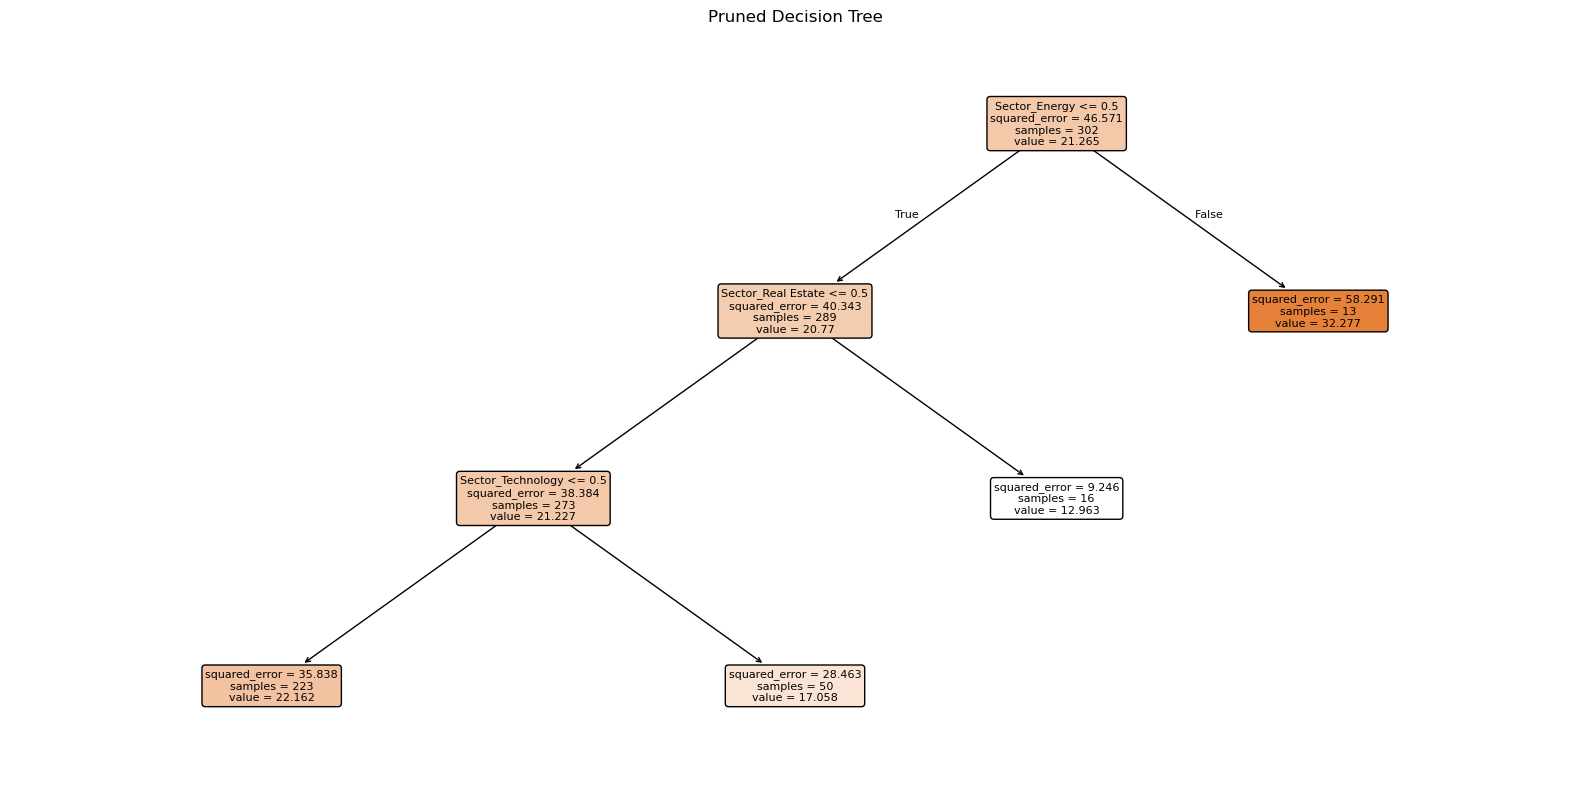


Saved image: images/decision_tree_plot.png


In [88]:
# ============================================================
# 19. Decision Tree with cost-complexity pruning
# ============================================================

print("\n" + "="*70)
print("Decision Tree Regression - cost-complexity pruning path")
print("="*70)

# Candidate ccp_alpha values from full training set after tree preprocessing
tree_preprocessor_for_path = clone(tree_preprocessor)
X_train_tree_for_path = tree_preprocessor_for_path.fit_transform(X_train_model)

tree_base_for_path = DecisionTreeRegressor(random_state=42)

path = tree_base_for_path.cost_complexity_pruning_path(
    X_train_tree_for_path,
    y_train
)

ccp_alphas = path.ccp_alphas[:-1]
ccp_alphas = np.unique(ccp_alphas)
ccp_alphas = ccp_alphas[ccp_alphas >= 0]

print("Number of candidate ccp_alpha values:", len(ccp_alphas))
print("First alpha:", ccp_alphas[0])
print("Last alpha:", ccp_alphas[-1])

tree_pipe = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_param_grid = {
    "model__ccp_alpha": ccp_alphas
}

tree_fitted, best_tree_params = evaluate_grid_model(
    model_name="Decision Tree",
    pipeline=tree_pipe,
    param_grid=tree_param_grid,
    dataset_type="nonlin",
    scaling="No scaling"
)

tree_depth = tree_fitted.named_steps["model"].get_depth()
tree_leaves = tree_fitted.named_steps["model"].get_n_leaves()

print("\nDecision Tree complexity:")
print("Best ccp_alpha:", best_tree_params["model__ccp_alpha"])
print("Tree depth:", tree_depth)
print("Number of leaves:", tree_leaves)

# Save decision tree plot
try:
    tree_feature_names = tree_fitted.named_steps["preprocessor"].get_feature_names_out()
    tree_feature_names = clean_feature_names(tree_feature_names)
except Exception:
    tree_feature_names = [f"x{i}" for i in range(tree_fitted.named_steps["model"].n_features_in_)]

plt.figure(figsize=(16, 8))
plot_tree(
    tree_fitted.named_steps["model"],
    feature_names=tree_feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Pruned Decision Tree")
plt.tight_layout()
plt.savefig("images/decision_tree_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved image: images/decision_tree_plot.png")




## Random forest

Tune and evaluate the random-forest model.

In [89]:
# ============================================================
# 20. Random Forest
# ============================================================

rf_pipe = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_features": ["sqrt", 0.5, 1.0],
    "model__min_samples_leaf": [1, 3, 5]
}

evaluate_grid_model(
    model_name="Random Forest",
    pipeline=rf_pipe,
    param_grid=rf_param_grid,
    dataset_type="nonlin",
    scaling="No scaling"
)





Random Forest
Best params:
{'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 500}
Best CV MSE from GridSearch: 31.425557862118108
Best CV RMSE from GridSearch: 5.605850324626774

CV MSE: 31.425557862118108
CV RMSE: 5.5982450458939494
CV MAE: 4.387671868852456
CV R2: 0.30568662472855157

Test MSE: 30.0364566610526
Test RMSE: 5.480552587198904
Test MAE: 4.287068421052625
Test R2: 0.3413998944275387


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('log',
                                                                    Log1pSelectedTransformer(feature_names=['Full '
                                                                                                            'Time '
                                                                                                            'Employees',
                                                                                                            'Controversy '
                                                                                                            'Score',
                                                          

## Bagging

Fit and evaluate the bagging regressor.

In [90]:
# ============================================================
# 21. Bagging
# ============================================================

base_tree = DecisionTreeRegressor(random_state=42)

if "estimator" in inspect.signature(BaggingRegressor).parameters:
    bagging_reg = BaggingRegressor(
        estimator=base_tree,
        random_state=42,
        n_jobs=-1
    )
else:
    bagging_reg = BaggingRegressor(
        base_estimator=base_tree,
        random_state=42,
        n_jobs=-1
    )

bagging_pipe = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", bagging_reg)
])

bagging_param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_samples": [0.5, 0.75, 1.0],
    "model__max_features": [0.5, 0.75, 1.0]
}

evaluate_grid_model(
    model_name="Bagging",
    pipeline=bagging_pipe,
    param_grid=bagging_param_grid,
    dataset_type="nonlin",
    scaling="No scaling"
)





Bagging
Best params:
{'model__max_features': 1.0, 'model__max_samples': 1.0, 'model__n_estimators': 100}
Best CV MSE from GridSearch: 31.527102177213116
Best CV RMSE from GridSearch: 5.614900014890124

CV MSE: 31.527102177213116
CV RMSE: 5.611719513761483
CV MAE: 4.433287704918032
CV R2: 0.30355208483620644

Test MSE: 29.27948713157895
Test RMSE: 5.411052312774194
Test MAE: 4.2291842105263155
Test R2: 0.35799773143781854


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('log',
                                                                    Log1pSelectedTransformer(feature_names=['Full '
                                                                                                            'Time '
                                                                                                            'Employees',
                                                                                                            'Controversy '
                                                                                                            'Score',
                                                          

## Gradient boosting

Tune and evaluate the gradient-boosting model.

In [91]:
# ============================================================
# 22. Gradient Boosting
# ============================================================

gb_pipe = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 5],
    "model__subsample": [0.8, 1.0]
}

evaluate_grid_model(
    model_name="Gradient Boosting",
    pipeline=gb_pipe,
    param_grid=gb_param_grid,
    dataset_type="nonlin",
    scaling="No scaling"
)





Gradient Boosting
Best params:
{'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__min_samples_leaf': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV MSE from GridSearch: 30.183415185389684
Best CV RMSE from GridSearch: 5.493943500382006

CV MSE: 30.183415185389684
CV RMSE: 5.489496066096117
CV MAE: 4.365055074366367
CV R2: 0.3282204293603367

Test MSE: 27.696789461500824
Test RMSE: 5.262773932205413
Test MAE: 4.184401124666821
Test R2: 0.39270105428196567


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('log',
                                                                    Log1pSelectedTransformer(feature_names=['Full '
                                                                                                            'Time '
                                                                                                            'Employees',
                                                                                                            'Controversy '
                                                                                                            'Score',
                                                          

## First model comparison

Collect the models estimated so far and inspect their relative performance.

In [92]:
# ============================================================
# 23. Final results table
# ============================================================

results_table = pd.DataFrame(results)

results_table = results_table.sort_values(
    by="Test_R2",
    ascending=False
).reset_index(drop=True)

print("\n" + "="*70)
print("FINAL RESULTS TABLE")
print("="*70)

display(results_table)

print("\nFinal ranking by Test_R2:")
display(
    results_table[
        ["Model", "CV_RMSE", "Test_RMSE", "CV_R2", "Test_R2", "Best_Params"]
    ]
)



print("\nSaved images:")
print("- images/correlation_matrix.png")
print("- images/linear_regression_actual_vs_predicted.png")
print("- images/decision_tree_plot.png")

display(Markdown("""
# SVM

### I used an RBF-kernel SVR (and not a linear kernel SVR) because the linear relationships were already covered by OLS, Ridge and Lasso. The RBF kernel allows the model to capture nonlinear patterns while keeping the preprocessing inside the pipeline.
"""))




FINAL RESULTS TABLE


,Model,Dataset_Type,Scaling,Best_Params,CV_MSE,Test_MSE,CV_RMSE,Test_RMSE,CV_MAE,Test_MAE,CV_R2,Test_R2
0,GAM,lin,Inside Pipeline,{'lambda': 1.0},2.647408e+01,2.623352e+01,5.138810e+00,5.121867,4.031798e+00,4.265687,4.158832e-01,0.424786
1,Linear Regression,lin,Inside Pipeline,None,2.670742e+01,2.764289e+01,5.163159e+00,5.257651,4.067921e+00,4.403579,4.100259e-01,0.393883
2,Gradient Boosting,nonlin,No scaling,"{'model__learning_rate': 0.03, 'model__max_dep...",3.018342e+01,2.769679e+01,5.489496e+00,5.262774,4.365055e+00,4.184401,3.282204e-01,0.392701
3,Ridge Regression,lin,Inside Pipeline,{'model__alpha': 3.351602650938848},2.664403e+01,2.784146e+01,5.156337e+00,5.276500,4.074475e+00,4.411653,4.118661e-01,0.389529
4,Lasso Regression,lin,Inside Pipeline,{'model__alpha': 0.040370172585965536},2.660490e+01,2.795110e+01,5.151820e+00,5.286880,4.083378e+00,4.421904,4.127483e-01,0.387125
5,Bagging,nonlin,No scaling,"{'model__max_features': 1.0, 'model__max_sampl...",3.152710e+01,2.927949e+01,5.611720e+00,5.411052,4.433288e+00,4.229184,3.035521e-01,0.357998
6,Random Forest,nonlin,No scaling,"{'model__max_features': 'sqrt', 'model__min_sa...",3.142556e+01,3.003646e+01,5.598245e+00,5.480553,4.387672e+00,4.287068,3.056866e-01,0.341400
7,Decision Tree,nonlin,No scaling,{'model__ccp_alpha': 2.1683775430874235},4.031969e+01,3.171198e+01,6.338409e+00,5.631339,5.052167e+00,4.406910,1.172080e-01,0.304661
8,Polynomial Regression degree 2,lin,Inside Pipeline,{'degree': 2},2.652387e+24,8.844477e+02,7.772418e+11,29.739665,1.304641e+11,8.695369,-7.126985e+22,-18.393011
9,Polynomial Regression degree 3,lin,Inside Pipeline,{'degree': 3},1.935016e+06,2.763856e+06,8.517931e+02,1662.484815,1.954010e+02,347.913316,-3.704718e+04,-60601.211380



Final ranking by Test_R2:


,Model,CV_RMSE,Test_RMSE,CV_R2,Test_R2,Best_Params
0,GAM,5.138810e+00,5.121867,4.158832e-01,0.424786,{'lambda': 1.0}
1,Linear Regression,5.163159e+00,5.257651,4.100259e-01,0.393883,None
2,Gradient Boosting,5.489496e+00,5.262774,3.282204e-01,0.392701,"{'model__learning_rate': 0.03, 'model__max_dep..."
3,Ridge Regression,5.156337e+00,5.276500,4.118661e-01,0.389529,{'model__alpha': 3.351602650938848}
4,Lasso Regression,5.151820e+00,5.286880,4.127483e-01,0.387125,{'model__alpha': 0.040370172585965536}
5,Bagging,5.611720e+00,5.411052,3.035521e-01,0.357998,"{'model__max_features': 1.0, 'model__max_sampl..."
6,Random Forest,5.598245e+00,5.480553,3.056866e-01,0.341400,"{'model__max_features': 'sqrt', 'model__min_sa..."
7,Decision Tree,6.338409e+00,5.631339,1.172080e-01,0.304661,{'model__ccp_alpha': 2.1683775430874235}
8,Polynomial Regression degree 2,7.772418e+11,29.739665,-7.126985e+22,-18.393011,{'degree': 2}
9,Polynomial Regression degree 3,8.517931e+02,1662.484815,-3.704718e+04,-60601.211380,{'degree': 3}



Saved images:
- images/correlation_matrix.png
- images/linear_regression_actual_vs_predicted.png
- images/decision_tree_plot.png



# SVM

### I used an RBF-kernel SVR (and not a linear kernel SVR) because the linear relationships were already covered by OLS, Ridge and Lasso. The RBF kernel allows the model to capture nonlinear patterns while keeping the preprocessing inside the pipeline.


## Support vector regression: tuning

Tune an RBF-kernel support vector regressor.

In [93]:
# ============================================================
# Support Vector Regression - RBF kernel tuning
# ============================================================

from sklearn.svm import SVR

print("Modello: Support Vector Regression")
print("Kernel: RBF")
print("Dataset usato: nonlin scaled")
print("Scaling X: sì, inside Pipeline")
print("Target y standardizzata: no")

# Preprocessor per modelli scale-sensitive:
# - numeric: median imputation + log-transform
# - categorical: mode imputation + rare grouping + full one-hot encoding
# - final scaling on the whole encoded matrix
scale_sensitive_column_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("log", Log1pSelectedTransformer(
                feature_names=numeric_features,
                log_cols=model_log_cols
            ))
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("rare", RareCategoryGrouper(
                feature_names=categorical_features,
                sector_col="Sector",
                controversy_col="Controversy Level",
                min_count=5
            )),
            ("onehot", make_ohe(drop=None))
        ]), categorical_features)
    ],
    remainder="drop"
)

scale_sensitive_preprocessor = Pipeline([
    ("columns", scale_sensitive_column_preprocessor),
    ("scaler", StandardScaler())
])

# Pipeline SVR con kernel RBF
svr_pipe = Pipeline([
    ("preprocessor", scale_sensitive_preprocessor),
    ("model", SVR(kernel="rbf"))
])

# Griglia di tuning
# C: penalizzazione degli errori
# epsilon: margine di tolleranza della regressione
# gamma: ampiezza del kernel RBF
svr_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__epsilon": [0.1, 0.5, 1.0],
    "model__gamma": ["scale", 0.01, 0.1, 1.0]
}

svr_grid = GridSearchCV(
    estimator=svr_pipe,
    param_grid=svr_param_grid,
    scoring="neg_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

svr_grid.fit(X_train_model, y_train)

best_svr_params = svr_grid.best_params_

print("Best parameters:")
print(best_svr_params)
print("Best CV MSE:", -svr_grid.best_score_)
print("Best CV RMSE:", np.sqrt(-svr_grid.best_score_))



Modello: Support Vector Regression
Kernel: RBF
Dataset usato: nonlin scaled
Scaling X: sì, inside Pipeline
Target y standardizzata: no
Best parameters:
{'model__C': 100, 'model__epsilon': 1.0, 'model__gamma': 0.01}
Best CV MSE: 26.393754787321647
Best CV RMSE: 5.137485259085582


## Support vector regression: evaluation

Evaluate the selected SVR and add it to the comparison table.

In [94]:
# ============================================================
# Support Vector Regression - final model and test evaluation
# ============================================================

# Miglior pipeline trovata dal GridSearchCV
svr_final = svr_grid.best_estimator_

# Cross-validation completa sul training set con i migliori parametri
svr_cv_results = cross_validate(
    estimator=svr_final,
    X=X_train_model,
    y=y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# Metriche CV
svr_cv_mse_scores = -svr_cv_results["test_mse"]
svr_cv_mae_scores = -svr_cv_results["test_mae"]
svr_cv_r2_scores = svr_cv_results["test_r2"]

svr_cv_mse = svr_cv_mse_scores.mean()
svr_cv_rmse = np.sqrt(svr_cv_mse_scores).mean()
svr_cv_mae = svr_cv_mae_scores.mean()
svr_cv_r2 = svr_cv_r2_scores.mean()

# Training finale sull'intero training set
svr_final.fit(X_train_model, y_train)

# Predizione sul test set
y_pred_svr = svr_final.predict(X_test_model)

# Metriche finali sul test set
svr_test_mse, svr_test_rmse, svr_test_mae, svr_test_r2 = regression_metrics(
    y_test,
    y_pred_svr
)

print("Best parameters:")
print(best_svr_params)

print("\nSVR RBF Test Metrics")
print("Test MSE:", svr_test_mse)
print("Test RMSE:", svr_test_rmse)
print("Test MAE:", svr_test_mae)
print("Test R2:", svr_test_r2)

# Aggiornamento tabella risultati
svr_result = pd.DataFrame([{
    "Model": "SVR RBF",
    "Dataset_Type": "nonlin_scaled",
    "Scaling": "Inside Pipeline",
    "Best_Params": best_svr_params,
    "CV_MSE": svr_cv_mse,
    "Test_MSE": svr_test_mse,
    "CV_RMSE": svr_cv_rmse,
    "Test_RMSE": svr_test_rmse,
    "CV_MAE": svr_cv_mae,
    "Test_MAE": svr_test_mae,
    "CV_R2": svr_cv_r2,
    "Test_R2": svr_test_r2
}])

# Evita duplicati se la cella viene rieseguita
results_table = results_table[
    results_table["Model"] != "SVR RBF"
].copy()

results_table = pd.concat(
    [results_table, svr_result],
    ignore_index=True
)

results_table = results_table.sort_values(
    by="Test_R2",
    ascending=False
).reset_index(drop=True)

display(results_table)

display(Markdown("""# Neural Network"""))



Best parameters:
{'model__C': 100, 'model__epsilon': 1.0, 'model__gamma': 0.01}

SVR RBF Test Metrics
Test MSE: 25.561463483815174
Test RMSE: 5.055834598146499
Test MAE: 4.07072948787537
Test R2: 0.43952168729487795


,Model,Dataset_Type,Scaling,Best_Params,CV_MSE,Test_MSE,CV_RMSE,Test_RMSE,CV_MAE,Test_MAE,CV_R2,Test_R2
0,SVR RBF,nonlin_scaled,Inside Pipeline,"{'model__C': 100, 'model__epsilon': 1.0, 'mode...",2.639375e+01,2.556146e+01,5.133304e+00,5.055835,4.019089e+00,4.070729,4.153064e-01,0.439522
1,GAM,lin,Inside Pipeline,{'lambda': 1.0},2.647408e+01,2.623352e+01,5.138810e+00,5.121867,4.031798e+00,4.265687,4.158832e-01,0.424786
2,Linear Regression,lin,Inside Pipeline,None,2.670742e+01,2.764289e+01,5.163159e+00,5.257651,4.067921e+00,4.403579,4.100259e-01,0.393883
3,Gradient Boosting,nonlin,No scaling,"{'model__learning_rate': 0.03, 'model__max_dep...",3.018342e+01,2.769679e+01,5.489496e+00,5.262774,4.365055e+00,4.184401,3.282204e-01,0.392701
4,Ridge Regression,lin,Inside Pipeline,{'model__alpha': 3.351602650938848},2.664403e+01,2.784146e+01,5.156337e+00,5.276500,4.074475e+00,4.411653,4.118661e-01,0.389529
5,Lasso Regression,lin,Inside Pipeline,{'model__alpha': 0.040370172585965536},2.660490e+01,2.795110e+01,5.151820e+00,5.286880,4.083378e+00,4.421904,4.127483e-01,0.387125
6,Bagging,nonlin,No scaling,"{'model__max_features': 1.0, 'model__max_sampl...",3.152710e+01,2.927949e+01,5.611720e+00,5.411052,4.433288e+00,4.229184,3.035521e-01,0.357998
7,Random Forest,nonlin,No scaling,"{'model__max_features': 'sqrt', 'model__min_sa...",3.142556e+01,3.003646e+01,5.598245e+00,5.480553,4.387672e+00,4.287068,3.056866e-01,0.341400
8,Decision Tree,nonlin,No scaling,{'model__ccp_alpha': 2.1683775430874235},4.031969e+01,3.171198e+01,6.338409e+00,5.631339,5.052167e+00,4.406910,1.172080e-01,0.304661
9,Polynomial Regression degree 2,lin,Inside Pipeline,{'degree': 2},2.652387e+24,8.844477e+02,7.772418e+11,29.739665,1.304641e+11,8.695369,-7.126985e+22,-18.393011


# Neural Network

## PyTorch neural network: data preparation

Prepare the transformed data and tensors for the custom neural network.

In [95]:
# ============================================================
# PyTorch Neural Network - data preparation
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.base import clone

print("Modello: Neural Network with PyTorch")
print("Dataset usato: nonlin scaled")
print("Scaling X: sì, inside preprocessing")
print("Target y standardizzata: no")

# Seed per riproducibilità
torch.manual_seed(42)
np.random.seed(42)

# Controllo che il preprocessor scale-sensitive sia già stato creato
try:
    scale_sensitive_preprocessor
except NameError:
    raise NameError(
        "scale_sensitive_preprocessor non è definito. "
        "Esegui prima la cella SVR in cui abbiamo creato il preprocessing nonlin scalato."
    )

# Validation split ricavato SOLO dal training set
X_train_nn_raw, X_val_nn_raw, y_train_nn_raw, y_val_nn_raw = train_test_split(
    X_train_model,
    y_train,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Fit del preprocessing solo sul sotto-training della rete
# così anche la validation resta pulita
nn_preprocessor = clone(scale_sensitive_preprocessor)

X_train_nn = nn_preprocessor.fit_transform(X_train_nn_raw)
X_val_nn = nn_preprocessor.transform(X_val_nn_raw)
X_test_nn = nn_preprocessor.transform(X_test_model)

# Conversione in tensori PyTorch
X_train_tensor = torch.tensor(X_train_nn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_nn_raw.values.reshape(-1, 1), dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_nn, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_nn_raw.values.reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_nn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

# Dataset e DataLoader
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("\nShapes:")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_val_tensor:", X_val_tensor.shape)
print("y_val_tensor:", y_val_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

print("\nNumber of input features:", X_train_tensor.shape[1])



Modello: Neural Network with PyTorch
Dataset usato: nonlin scaled
Scaling X: sì, inside preprocessing
Target y standardizzata: no

Shapes:
X_train_tensor: torch.Size([241, 18])
y_train_tensor: torch.Size([241, 1])
X_val_tensor: torch.Size([61, 18])
y_val_tensor: torch.Size([61, 1])
X_test_tensor: torch.Size([76, 18])
y_test_tensor: torch.Size([76, 1])

Number of input features: 18


## PyTorch neural network: training

Define the architecture, train the model and apply early stopping.

Epoch 050 | Train Loss: 29.2569 | Val Loss: 30.3373
Epoch 100 | Train Loss: 23.7444 | Val Loss: 27.5723
Epoch 150 | Train Loss: 21.0383 | Val Loss: 27.4644

Early stopping at epoch 176

Best validation MSE: 26.936206817626953
Best validation RMSE: 5.190010290705304


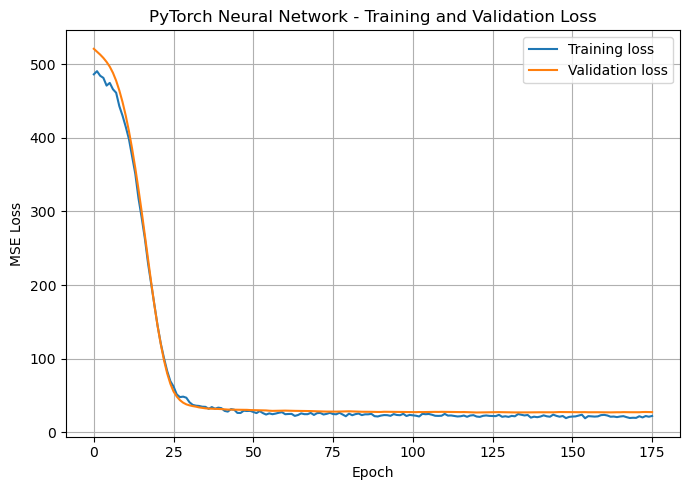


Saved image: images/pytorch_nn.png



### PyTorch is not the model itself, but the library I used to define the neural network. I built a feed-forward architecture with two hidden layers, 32 and 16 neurons. ReLU was used as activation function to introduce non-linearity. The model minimized MSE loss, and Adam was used to update the weights. I used dropout and early stopping to control overfitting. For the PyTorch Neural Network, I did not use 5-fold cross-validation. I used a single internal validation split to monitor validation loss and apply early stopping. The architecture and main hyperparameters were fixed beforehand rather than selected through a full grid search.


In [96]:
# ============================================================
# PyTorch Neural Network - model architecture and training
# ============================================================

class ESGNet(nn.Module):
    def __init__(self, input_dim):
        super(ESGNet, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 1)
        )
    
    def forward(self, x):
        return self.network(x)


# Modello
input_dim = X_train_tensor.shape[1]
torch_model = ESGNet(input_dim)

# Loss e optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    torch_model.parameters(),
    lr=0.001,
    weight_decay=0.001
)

# Training settings
n_epochs = 500
patience = 40

train_losses = []
val_losses = []

best_val_loss = np.inf
best_model_state = None
epochs_without_improvement = 0

for epoch in range(n_epochs):
    
    # ------------------------
    # Training phase
    # ------------------------
    torch_model.train()
    batch_train_losses = []
    
    for X_batch, y_batch in train_loader:
        
        optimizer.zero_grad()
        
        y_pred_batch = torch_model(X_batch)
        loss = criterion(y_pred_batch, y_batch)
        
        loss.backward()
        optimizer.step()
        
        batch_train_losses.append(loss.item())
    
    train_loss = np.mean(batch_train_losses)
    train_losses.append(train_loss)
    
    # ------------------------
    # Validation phase
    # ------------------------
    torch_model.eval()
    batch_val_losses = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred_batch = torch_model(X_batch)
            val_loss = criterion(y_pred_batch, y_batch)
            batch_val_losses.append(val_loss.item())
    
    val_loss = np.mean(batch_val_losses)
    val_losses.append(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = torch_model.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    
    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch {epoch + 1:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )
    
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break

# Ripristiniamo il modello migliore sulla validation loss
torch_model.load_state_dict(best_model_state)

print("\nBest validation MSE:", best_val_loss)
print("Best validation RMSE:", np.sqrt(best_val_loss))

# Grafico training vs validation loss
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.title("PyTorch Neural Network - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/pytorch_nn.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved image: images/pytorch_nn.png")

display(Markdown(f"""
### PyTorch is not the model itself, but the library I used to define the neural network. I built a feed-forward architecture with two hidden layers, 32 and 16 neurons. ReLU was used as activation function to introduce non-linearity. The model minimized MSE loss, and Adam was used to update the weights. I used dropout and early stopping to control overfitting. For the PyTorch Neural Network, I did not use 5-fold cross-validation. I used a single internal validation split to monitor validation loss and apply early stopping. The architecture and main hyperparameters were fixed beforehand rather than selected through a full grid search.
"""))



## PyTorch neural network: evaluation

Evaluate the trained network and add its metrics to the results table.

In [97]:
# ============================================================
# PyTorch Neural Network - test evaluation and results table
# ============================================================

torch_model.eval()

with torch.no_grad():
    y_pred_torch_tensor = torch_model(X_test_tensor)

# Convertiamo le predizioni in numpy array
y_pred_torch = y_pred_torch_tensor.numpy().flatten()

# Metriche finali sul test set
torch_test_mse, torch_test_rmse, torch_test_mae, torch_test_r2 = regression_metrics(
    y_test,
    y_pred_torch
)

print("PyTorch Neural Network Test Metrics")
print("Test MSE:", torch_test_mse)
print("Test RMSE:", torch_test_rmse)
print("Test MAE:", torch_test_mae)
print("Test R2:", torch_test_r2)

# Per la parte CV/validation nella tabella usiamo la validation performance interna
# perché per PyTorch abbiamo usato validation split e early stopping, non 5-fold CV
torch_val_mse = best_val_loss
torch_val_rmse = np.sqrt(best_val_loss)

with torch.no_grad():
    y_pred_val_tensor = torch_model(X_val_tensor)

y_pred_val = y_pred_val_tensor.numpy().flatten()

torch_val_mae = mean_absolute_error(y_val_nn_raw, y_pred_val)
torch_val_r2 = r2_score(y_val_nn_raw, y_pred_val)

# Aggiornamento tabella risultati
torch_result = pd.DataFrame([{
    "Model": "PyTorch Neural Network",
    "Dataset_Type": "nonlin_scaled",
    "Scaling": "Inside preprocessing",
    "Best_Params": {
        "hidden_layers": [32, 16],
        "dropout": 0.10,
        "lr": 0.001,
        "weight_decay": 0.001,
        "batch_size": batch_size,
        "early_stopping": True
    },
    "CV_MSE": torch_val_mse,
    "Test_MSE": torch_test_mse,
    "CV_RMSE": torch_val_rmse,
    "Test_RMSE": torch_test_rmse,
    "CV_MAE": torch_val_mae,
    "Test_MAE": torch_test_mae,
    "CV_R2": torch_val_r2,
    "Test_R2": torch_test_r2
}])

# Evita duplicati se la cella viene rieseguita
results_table = results_table[
    results_table["Model"] != "PyTorch Neural Network"
].copy()

results_table = pd.concat(
    [results_table, torch_result],
    ignore_index=True
)

results_table = results_table.sort_values(
    by="Test_R2",
    ascending=False
).reset_index(drop=True)

display(results_table)



PyTorch Neural Network Test Metrics
Test MSE: 24.1529517256553
Test RMSE: 4.914565263139284
Test MAE: 3.9680057500538077
Test R2: 0.4704056894623838


,Model,Dataset_Type,Scaling,Best_Params,CV_MSE,Test_MSE,CV_RMSE,Test_RMSE,CV_MAE,Test_MAE,CV_R2,Test_R2
0,PyTorch Neural Network,nonlin_scaled,Inside preprocessing,"{'hidden_layers': [32, 16], 'dropout': 0.1, 'l...",2.693621e+01,2.415295e+01,5.190010e+00,4.914565,4.212196e+00,3.968006,4.152099e-01,0.470406
1,SVR RBF,nonlin_scaled,Inside Pipeline,"{'model__C': 100, 'model__epsilon': 1.0, 'mode...",2.639375e+01,2.556146e+01,5.133304e+00,5.055835,4.019089e+00,4.070729,4.153064e-01,0.439522
2,GAM,lin,Inside Pipeline,{'lambda': 1.0},2.647408e+01,2.623352e+01,5.138810e+00,5.121867,4.031798e+00,4.265687,4.158832e-01,0.424786
3,Linear Regression,lin,Inside Pipeline,None,2.670742e+01,2.764289e+01,5.163159e+00,5.257651,4.067921e+00,4.403579,4.100259e-01,0.393883
4,Gradient Boosting,nonlin,No scaling,"{'model__learning_rate': 0.03, 'model__max_dep...",3.018342e+01,2.769679e+01,5.489496e+00,5.262774,4.365055e+00,4.184401,3.282204e-01,0.392701
5,Ridge Regression,lin,Inside Pipeline,{'model__alpha': 3.351602650938848},2.664403e+01,2.784146e+01,5.156337e+00,5.276500,4.074475e+00,4.411653,4.118661e-01,0.389529
6,Lasso Regression,lin,Inside Pipeline,{'model__alpha': 0.040370172585965536},2.660490e+01,2.795110e+01,5.151820e+00,5.286880,4.083378e+00,4.421904,4.127483e-01,0.387125
7,Bagging,nonlin,No scaling,"{'model__max_features': 1.0, 'model__max_sampl...",3.152710e+01,2.927949e+01,5.611720e+00,5.411052,4.433288e+00,4.229184,3.035521e-01,0.357998
8,Random Forest,nonlin,No scaling,"{'model__max_features': 'sqrt', 'model__min_sa...",3.142556e+01,3.003646e+01,5.598245e+00,5.480553,4.387672e+00,4.287068,3.056866e-01,0.341400
9,Decision Tree,nonlin,No scaling,{'model__ccp_alpha': 2.1683775430874235},4.031969e+01,3.171198e+01,6.338409e+00,5.631339,5.052167e+00,4.406910,1.172080e-01,0.304661


## MLPRegressor: tuning

Tune the scikit-learn multilayer perceptron.

In [98]:
# ============================================================
# MLPRegressor Neural Network - hyperparameter tuning
# ============================================================

from sklearn.neural_network import MLPRegressor

print("Modello: Neural Network with MLPRegressor")
print("Dataset usato: nonlin scaled")
print("Scaling X: sì, inside Pipeline")
print("Target y standardizzata: no")

# Pipeline MLPRegressor
mlp_pipe = Pipeline([
    ("preprocessor", scale_sensitive_preprocessor),
    ("model", MLPRegressor(
        activation="relu",
        solver="adam",
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=42
    ))
])

# Griglia di tuning
# hidden_layer_sizes: architettura della rete
# alpha: regolarizzazione L2
# learning_rate_init: learning rate iniziale dell'optimizer Adam
mlp_param_grid = {
    "model__hidden_layer_sizes": [
        (32,),
        (32, 16),
        (64, 32)
    ],
    "model__alpha": [
        0.0001,
        0.001,
        0.01
    ],
    "model__learning_rate_init": [
        0.001,
        0.0005
    ]
}

# Tuning con 5-fold CV solo sul training set
mlp_grid = GridSearchCV(
    estimator=mlp_pipe,
    param_grid=mlp_param_grid,
    scoring="neg_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

mlp_grid.fit(X_train_model, y_train)

best_mlp_params = mlp_grid.best_params_

print("Best parameters:")
print(best_mlp_params)
print("Best CV MSE:", -mlp_grid.best_score_)
print("Best CV RMSE:", np.sqrt(-mlp_grid.best_score_))



Modello: Neural Network with MLPRegressor
Dataset usato: nonlin scaled
Scaling X: sì, inside Pipeline
Target y standardizzata: no
Best parameters:
{'model__alpha': 0.0001, 'model__hidden_layer_sizes': (32, 16), 'model__learning_rate_init': 0.001}
Best CV MSE: 27.665194764454288
Best CV RMSE: 5.259771360473218


## MLPRegressor: evaluation

Evaluate the selected MLPRegressor and update the results table.

In [99]:
# ============================================================
# MLPRegressor Neural Network - final model and test evaluation
# ============================================================

# Miglior pipeline trovata dal GridSearchCV
mlp_final = mlp_grid.best_estimator_

# Cross-validation completa sul training set con i migliori parametri
mlp_cv_results = cross_validate(
    estimator=mlp_final,
    X=X_train_model,
    y=y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# Metriche CV
mlp_cv_mse_scores = -mlp_cv_results["test_mse"]
mlp_cv_mae_scores = -mlp_cv_results["test_mae"]
mlp_cv_r2_scores = mlp_cv_results["test_r2"]

mlp_cv_mse = mlp_cv_mse_scores.mean()
mlp_cv_rmse = np.sqrt(mlp_cv_mse_scores).mean()
mlp_cv_mae = mlp_cv_mae_scores.mean()
mlp_cv_r2 = mlp_cv_r2_scores.mean()

# Training finale sull'intero training set
mlp_final.fit(X_train_model, y_train)

# Predizione sul test set
y_pred_mlp = mlp_final.predict(X_test_model)

# Metriche finali sul test set
mlp_test_mse, mlp_test_rmse, mlp_test_mae, mlp_test_r2 = regression_metrics(
    y_test,
    y_pred_mlp
)

print("Best parameters:")
print(best_mlp_params)

print("\nMLPRegressor Test Metrics")
print("Test MSE:", mlp_test_mse)
print("Test RMSE:", mlp_test_rmse)
print("Test MAE:", mlp_test_mae)
print("Test R2:", mlp_test_r2)

# Aggiornamento tabella risultati
mlp_result = pd.DataFrame([{
    "Model": "MLPRegressor Neural Network",
    "Dataset_Type": "nonlin_scaled",
    "Scaling": "Inside Pipeline",
    "Best_Params": best_mlp_params,
    "CV_MSE": mlp_cv_mse,
    "Test_MSE": mlp_test_mse,
    "CV_RMSE": mlp_cv_rmse,
    "Test_RMSE": mlp_test_rmse,
    "CV_MAE": mlp_cv_mae,
    "Test_MAE": mlp_test_mae,
    "CV_R2": mlp_cv_r2,
    "Test_R2": mlp_test_r2
}])

# Evita duplicati se la cella viene rieseguita
results_table = results_table[
    results_table["Model"] != "MLPRegressor Neural Network"
].copy()

results_table = pd.concat(
    [results_table, mlp_result],
    ignore_index=True
)

results_table = results_table.sort_values(
    by="Test_R2",
    ascending=False
).reset_index(drop=True)

display(results_table)



Best parameters:
{'model__alpha': 0.0001, 'model__hidden_layer_sizes': (32, 16), 'model__learning_rate_init': 0.001}

MLPRegressor Test Metrics
Test MSE: 26.640803046835007
Test RMSE: 5.1614729532213
Test MAE: 4.2305483575776055
Test R2: 0.4158553421538701


,Model,Dataset_Type,Scaling,Best_Params,CV_MSE,Test_MSE,CV_RMSE,Test_RMSE,CV_MAE,Test_MAE,CV_R2,Test_R2
0,PyTorch Neural Network,nonlin_scaled,Inside preprocessing,"{'hidden_layers': [32, 16], 'dropout': 0.1, 'l...",2.693621e+01,2.415295e+01,5.190010e+00,4.914565,4.212196e+00,3.968006,4.152099e-01,0.470406
1,SVR RBF,nonlin_scaled,Inside Pipeline,"{'model__C': 100, 'model__epsilon': 1.0, 'mode...",2.639375e+01,2.556146e+01,5.133304e+00,5.055835,4.019089e+00,4.070729,4.153064e-01,0.439522
2,GAM,lin,Inside Pipeline,{'lambda': 1.0},2.647408e+01,2.623352e+01,5.138810e+00,5.121867,4.031798e+00,4.265687,4.158832e-01,0.424786
3,MLPRegressor Neural Network,nonlin_scaled,Inside Pipeline,"{'model__alpha': 0.0001, 'model__hidden_layer_...",2.766519e+01,2.664080e+01,5.254792e+00,5.161473,4.163821e+00,4.230548,3.834514e-01,0.415855
4,Linear Regression,lin,Inside Pipeline,None,2.670742e+01,2.764289e+01,5.163159e+00,5.257651,4.067921e+00,4.403579,4.100259e-01,0.393883
5,Gradient Boosting,nonlin,No scaling,"{'model__learning_rate': 0.03, 'model__max_dep...",3.018342e+01,2.769679e+01,5.489496e+00,5.262774,4.365055e+00,4.184401,3.282204e-01,0.392701
6,Ridge Regression,lin,Inside Pipeline,{'model__alpha': 3.351602650938848},2.664403e+01,2.784146e+01,5.156337e+00,5.276500,4.074475e+00,4.411653,4.118661e-01,0.389529
7,Lasso Regression,lin,Inside Pipeline,{'model__alpha': 0.040370172585965536},2.660490e+01,2.795110e+01,5.151820e+00,5.286880,4.083378e+00,4.421904,4.127483e-01,0.387125
8,Bagging,nonlin,No scaling,"{'model__max_features': 1.0, 'model__max_sampl...",3.152710e+01,2.927949e+01,5.611720e+00,5.411052,4.433288e+00,4.229184,3.035521e-01,0.357998
9,Random Forest,nonlin,No scaling,"{'model__max_features': 'sqrt', 'model__min_sa...",3.142556e+01,3.003646e+01,5.598245e+00,5.480553,4.387672e+00,4.287068,3.056866e-01,0.341400


## Compact final comparison

Create the compact ranking used to summarize the predictive results.

In [100]:
# ============================================================
# 28. Compact Final Model Comparison
# ============================================================

final_comparison = results_table[[
    "Model",
    "Test_RMSE",
    "Test_MAE",
    "Test_R2"
]].copy()

final_comparison = final_comparison.rename(columns={
    "Test_RMSE": "Test RMSE",
    "Test_MAE": "Test MAE",
    "Test_R2": "Test R2"
})

final_comparison_compact = final_comparison[
    ~final_comparison["Model"].str.contains("Polynomial", case=False, na=False)
].copy()

final_comparison_compact["Test RMSE"] = final_comparison_compact["Test RMSE"].round(3)
final_comparison_compact["Test MAE"] = final_comparison_compact["Test MAE"].round(3)
final_comparison_compact["Test R2"] = final_comparison_compact["Test R2"].round(3)

final_comparison_compact = final_comparison_compact.sort_values(
    by="Test R2",
    ascending=False
).reset_index(drop=True)

print("\n" + "="*70)
print("COMPACT FINAL MODEL COMPARISON")
print("="*70)
display(final_comparison_compact)

print("\nFinal predictors used in the model pipelines:")
print(X_train_model.columns.tolist())

print("\nFinal numeric predictors:")
print(numeric_features)

print("\nFinal categorical predictors:")
print(categorical_features)

print("\nVariables removed before modelling:")
print({
    "identifiers_text_technical_target": cols_to_drop,
    "high_multicollinearity": high_corr_to_drop,
    "constant_columns": constant_cols
})



COMPACT FINAL MODEL COMPARISON


,Model,Test RMSE,Test MAE,Test R2
0,PyTorch Neural Network,4.915,3.968,0.470
1,SVR RBF,5.056,4.071,0.440
2,GAM,5.122,4.266,0.425
3,MLPRegressor Neural Network,5.161,4.231,0.416
4,Linear Regression,5.258,4.404,0.394
5,Gradient Boosting,5.263,4.184,0.393
6,Ridge Regression,5.277,4.412,0.390
7,Lasso Regression,5.287,4.422,0.387
8,Bagging,5.411,4.229,0.358
9,Random Forest,5.481,4.287,0.341



Final predictors used in the model pipelines:
['Sector', 'Full Time Employees', 'Controversy Score', 'Revenue', 'Operating Income (Loss)', 'Cash, Cash Equivalents & Short Term Investments', 'Total Assets', 'Change in Fixed Assets & Intangibles']

Final numeric predictors:
['Full Time Employees', 'Controversy Score', 'Revenue', 'Operating Income (Loss)', 'Cash, Cash Equivalents & Short Term Investments', 'Total Assets', 'Change in Fixed Assets & Intangibles']

Final categorical predictors:
['Sector']

Variables removed before modelling:
{'identifiers_text_technical_target': ['Symbol', 'Name', 'Address', 'Description', 'SimFinId', 'Financial_Statement_Type', 'Financial_Fiscal_Year', 'Total ESG Risk score', 'Environment Risk Score', 'Governance Risk Score', 'Social Risk Score', 'ESG Risk Percentile', 'ESG Risk Level', 'Industry', 'Controversy Level'], 'high_multicollinearity': ['Net Income', 'Net Cash from Operating Activities', 'Total Liabilities'], 'constant_columns': []}


# Final Table

In [101]:
# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

final_comparison = results_table[
    [
        "Model",
        "Test_RMSE",
        "Test_MAE",
        "Test_R2"
    ]
].copy()

# Rename columns for presentation
final_comparison = final_comparison.rename(columns={
    "Test_RMSE": "Test RMSE",
    "Test_MAE": "Test MAE",
    "Test_R2": "Test R²"
})

# Exclude Polynomial Regression from the compact final table
# because it was already discussed separately as a severe overfitting case
final_comparison = final_comparison[
    ~final_comparison["Model"].str.contains("Polynomial", case=False, na=False)
].copy()

# Round metrics for presentation
final_comparison["Test RMSE"] = final_comparison["Test RMSE"].round(3)
final_comparison["Test MAE"] = final_comparison["Test MAE"].round(3)
final_comparison["Test R²"] = final_comparison["Test R²"].round(3)

# Sort by best Test R²
final_comparison = final_comparison.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

print("Final Model Comparison")
print("Models are compared using the same held-out test set.")
print("Polynomial Regression models are excluded from this compact table because they showed severe overfitting.")
print()

display(final_comparison)



Final Model Comparison
Models are compared using the same held-out test set.
Polynomial Regression models are excluded from this compact table because they showed severe overfitting.



,Model,Test RMSE,Test MAE,Test R²
0,PyTorch Neural Network,4.915,3.968,0.470
1,SVR RBF,5.056,4.071,0.440
2,GAM,5.122,4.266,0.425
3,MLPRegressor Neural Network,5.161,4.231,0.416
4,Linear Regression,5.258,4.404,0.394
5,Gradient Boosting,5.263,4.184,0.393
6,Ridge Regression,5.277,4.412,0.390
7,Lasso Regression,5.287,4.422,0.387
8,Bagging,5.411,4.229,0.358
9,Random Forest,5.481,4.287,0.341


# Interpretation Linear Regression

### Statsmodels OLS table on transformed training data

In [102]:
# ============================================================
# INTERPRETATION BEST LINEAR MODEL: LINEAR REGRESSION
# Statsmodels OLS table on transformed training data
# ============================================================

import statsmodels.api as sm

print("=" * 80)
print("BEST LINEAR MODEL INTERPRETATION: LINEAR REGRESSION")
print("=" * 80)



BEST LINEAR MODEL INTERPRETATION: LINEAR REGRESSION


### 1. Retrieve fitted Linear Regression pipeline

In [103]:
# ------------------------------------------------------------
# 1. Retrieve fitted Linear Regression pipeline
# ------------------------------------------------------------

best_linear_pipeline = fitted_models["Linear Regression"]

linear_fitted_preprocessor = best_linear_pipeline.named_steps["preprocessor"]
linear_sklearn_model = best_linear_pipeline.named_steps["model"]



### 2. Transform X_train using the exact same preprocessing pipeline

In [104]:
# ------------------------------------------------------------
# 2. Transform X_train using the exact same preprocessing pipeline
# ------------------------------------------------------------

X_train_linear_transformed = linear_fitted_preprocessor.transform(X_train_model)

# Retrieve feature names after preprocessing
try:
    linear_feature_names = (
        linear_fitted_preprocessor
        .named_steps["columns"]
        .get_feature_names_out()
    )
    linear_feature_names = clean_feature_names(linear_feature_names)
except Exception:
    linear_feature_names = [
        f"x{i}" for i in range(X_train_linear_transformed.shape[1])
    ]

# Make feature names more readable in outputs
linear_feature_names_pretty = pretty_feature_names(linear_feature_names)

X_train_linear_df = pd.DataFrame(
    X_train_linear_transformed,
    columns=linear_feature_names_pretty,
    index=X_train_model.index
)



### 3. Print baseline category used in linear one-hot encoding

In [105]:
# ------------------------------------------------------------
# 3. Print baseline category used in linear one-hot encoding
# ------------------------------------------------------------

print("\nBaseline category removed in the linear model one-hot encoding:")

try:
    fitted_linear_columns = linear_fitted_preprocessor.named_steps["columns"]
    fitted_cat_pipe = fitted_linear_columns.named_transformers_["cat"]
    fitted_ohe = fitted_cat_pipe.named_steps["onehot"]

    for col, cats in zip(categorical_features, fitted_ohe.categories_):
        print(f"- {col}: {cats[0]}")

except Exception as e:
    print("Could not retrieve baseline category.")
    print("Reason:", e)




Baseline category removed in the linear model one-hot encoding:
- Sector: Basic Materials


### 4. Fit statsmodels OLS on transformed training data

In [106]:
# ------------------------------------------------------------
# 4. Fit statsmodels OLS on transformed training data
# ------------------------------------------------------------

X_train_linear_sm = sm.add_constant(X_train_linear_df)

ols_results = sm.OLS(
    y_train.astype(float),
    X_train_linear_sm.astype(float)
).fit()

print("\nStatsmodels OLS summary:")
print(ols_results.summary())




Statsmodels OLS summary:
                             OLS Regression Results                             
Dep. Variable:     Total ESG Risk score   R-squared:                       0.491
Model:                              OLS   Adj. R-squared:                  0.460
Method:                   Least Squares   F-statistic:                     16.10
Date:                  Wed, 05 Aug 2026   Prob (F-statistic):           1.49e-32
Time:                          10:47:59   Log-Likelihood:                -906.59
No. Observations:                   302   AIC:                             1849.
Df Residuals:                       284   BIC:                             1916.
Df Model:                            17                                         
Covariance Type:              nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

### 5. Create clean coefficient table

In [107]:
# ------------------------------------------------------------
# 5. Create clean coefficient table
# ------------------------------------------------------------

conf_int = ols_results.conf_int()
conf_int.columns = ["CI_lower", "CI_upper"]

ols_coef_table = pd.DataFrame({
    "Feature": ols_results.params.index,
    "Coefficient": ols_results.params.values,
    "Std_Error": ols_results.bse.values,
    "t_stat": ols_results.tvalues.values,
    "p_value": ols_results.pvalues.values,
    "CI_lower": conf_int["CI_lower"].values,
    "CI_upper": conf_int["CI_upper"].values
})

# Remove intercept from coefficient ranking table
ols_coef_table_no_const = ols_coef_table[
    ols_coef_table["Feature"] != "const"
].copy()

ols_coef_table_no_const["Abs_Coefficient"] = (
    ols_coef_table_no_const["Coefficient"].abs()
)

ols_coef_table_no_const = ols_coef_table_no_const.sort_values(
    by="Abs_Coefficient",
    ascending=False
).reset_index(drop=True)

# Rounded version for display
ols_coef_table_display = ols_coef_table_no_const.copy()

for col in [
    "Coefficient",
    "Std_Error",
    "t_stat",
    "p_value",
    "CI_lower",
    "CI_upper",
    "Abs_Coefficient"
]:
    ols_coef_table_display[col] = ols_coef_table_display[col].round(4)

print("\nLinear Regression coefficient table ordered by absolute coefficient:")
display(ols_coef_table_display)




Linear Regression coefficient table ordered by absolute coefficient:


,Feature,Coefficient,Std_Error,t_stat,p_value,CI_lower,CI_upper,Abs_Coefficient
0,Sector_Real Estate,-3.3120,0.4303,-7.6964,0.0000,-4.1591,-2.4650,3.3120
1,Sector_Technology,-3.1734,0.5697,-5.5703,0.0000,-4.2947,-2.0520,3.1734
2,Sector_Consumer Cyclical,-2.1969,0.5535,-3.9691,0.0001,-3.2864,-1.1074,2.1969
3,Sector_Healthcare,-1.9246,0.5184,-3.7126,0.0002,-2.9450,-0.9042,1.9246
4,Sector_Financial Services,-1.8991,0.5390,-3.5230,0.0005,-2.9601,-0.8380,1.8991
5,Revenue,-1.6332,0.7093,-2.3026,0.0220,-3.0294,-0.2371,1.6332
6,Total Assets,1.5916,0.6619,2.4047,0.0168,0.2888,2.8943,1.5916
7,Employees,-1.4912,0.5400,-2.7616,0.0061,-2.5541,-0.4284,1.4912
8,Controversy Score,1.4446,0.3733,3.8699,0.0001,0.7098,2.1793,1.4446
9,Sector_Communication Services,-1.3414,0.3707,-3.6185,0.0004,-2.0711,-0.6117,1.3414


### 6. Strongest positive and negative predictive associations

In [108]:
# ------------------------------------------------------------
# 6. Strongest positive and negative predictive associations
# ------------------------------------------------------------

print("\nStrongest positive predictive associations:")
display(
    ols_coef_table_display[
        ols_coef_table_display["Coefficient"] > 0
    ]
    .sort_values(by="Coefficient", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("\nStrongest negative predictive associations:")
display(
    ols_coef_table_display[
        ols_coef_table_display["Coefficient"] < 0
    ]
    .sort_values(by="Coefficient", ascending=True)
    .head(10)
    .reset_index(drop=True)
)




Strongest positive predictive associations:


,Feature,Coefficient,Std_Error,t_stat,p_value,CI_lower,CI_upper,Abs_Coefficient
0,Total Assets,1.5916,0.6619,2.4047,0.0168,0.2888,2.8943,1.5916
1,Controversy Score,1.4446,0.3733,3.8699,0.0001,0.7098,2.1793,1.4446
2,Sector_Energy,0.7908,0.4076,1.9400,0.0534,-0.0116,1.5931,0.7908
3,Cash & ST Investments,0.5498,0.4499,1.2220,0.2227,-0.3358,1.4354,0.5498
4,Operating Income,0.0667,0.3962,0.1683,0.8665,-0.7133,0.8466,0.0667
5,Sector_Consumer Defensive,0.0098,0.4793,0.0204,0.9838,-0.9337,0.9532,0.0098



Strongest negative predictive associations:


,Feature,Coefficient,Std_Error,t_stat,p_value,CI_lower,CI_upper,Abs_Coefficient
0,Sector_Real Estate,-3.3120,0.4303,-7.6964,0.0000,-4.1591,-2.4650,3.3120
1,Sector_Technology,-3.1734,0.5697,-5.5703,0.0000,-4.2947,-2.0520,3.1734
2,Sector_Consumer Cyclical,-2.1969,0.5535,-3.9691,0.0001,-3.2864,-1.1074,2.1969
3,Sector_Healthcare,-1.9246,0.5184,-3.7126,0.0002,-2.9450,-0.9042,1.9246
4,Sector_Financial Services,-1.8991,0.5390,-3.5230,0.0005,-2.9601,-0.8380,1.8991
5,Revenue,-1.6332,0.7093,-2.3026,0.0220,-3.0294,-0.2371,1.6332
6,Employees,-1.4912,0.5400,-2.7616,0.0061,-2.5541,-0.4284,1.4912
7,Sector_Communication Services,-1.3414,0.3707,-3.6185,0.0004,-2.0711,-0.6117,1.3414
8,Change in Fixed Assets & Intangibles,-1.2088,0.3825,-3.1605,0.0017,-1.9617,-0.4560,1.2088
9,Sector_Industrials,-0.5310,0.5277,-1.0062,0.3152,-1.5698,0.5078,0.5310


### 7. Coefficient plot

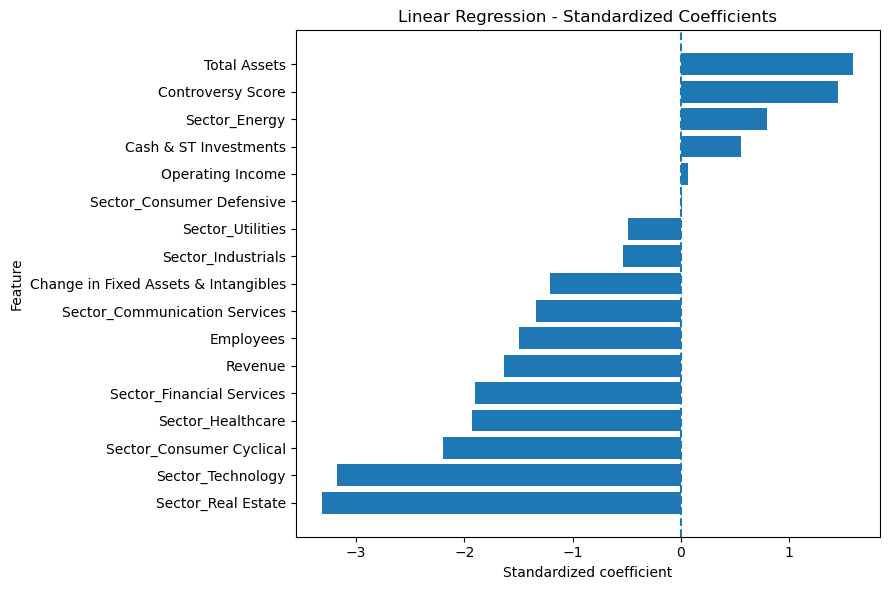


Saved image: images/linear_regression_statsmodels_coefficients.png


In [109]:
# ------------------------------------------------------------
# 7. Coefficient plot
# ------------------------------------------------------------

coef_plot_data = ols_coef_table_no_const.sort_values(
    by="Coefficient",
    ascending=True
)

plt.figure(figsize=(9, max(6, 0.35 * len(coef_plot_data))))

plt.barh(
    coef_plot_data["Feature"],
    coef_plot_data["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.title("Linear Regression - Standardized Coefficients")
plt.xlabel("Standardized coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "images/linear_regression_statsmodels_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved image: images/linear_regression_statsmodels_coefficients.png")



# Interpretation NN Pytorch (via Shap)

######  Interpretation of the Best Nonlinear Model: PyTorch Neural Network with SHAP. The best overall model is the PyTorch Neural Network. Since neural networks are black-box models and do not provide regression coefficients, I use SHAP values to interpret the model. SHAP values measure how much each feature contributes to individual model predictions. For a global interpretation, I compute the mean absolute SHAP value of each feature on the test set. Larger values indicate features that contribute more to the neural network predictions. The interpretation is based on feature importance, not on causal effects.

### Step 1

In [110]:
# ============================================================
# INTERPRETATION BEST NONLINEAR MODEL: PYTORCH NN WITH SHAP
# ============================================================

print("=" * 80)
print("BEST NONLINEAR MODEL INTERPRETATION: PYTORCH NEURAL NETWORK WITH SHAP")
print("=" * 80)



BEST NONLINEAR MODEL INTERPRETATION: PYTORCH NEURAL NETWORK WITH SHAP


### 1. Import SHAP

In [111]:
# ------------------------------------------------------------
# 1. Import SHAP
# ------------------------------------------------------------

try:
    import shap
except ImportError:
    raise ImportError(
        "The package 'shap' is not installed. "
        "Install it with: pip install shap"
    )



### 2. Put PyTorch model in evaluation mode

In [112]:
# ------------------------------------------------------------
# 2. Put PyTorch model in evaluation mode
# ------------------------------------------------------------

torch_model.eval()



ESGNet(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)

### 3. Retrieve feature names after the neural-network preprocessing

In [113]:
# ------------------------------------------------------------
# 3. Retrieve feature names after the neural-network preprocessing
# ------------------------------------------------------------

try:
    nn_feature_names = (
        nn_preprocessor
        .named_steps["columns"]
        .get_feature_names_out()
    )
    
    nn_feature_names = clean_feature_names(nn_feature_names)
    nn_feature_names = pretty_feature_names(nn_feature_names)

except Exception:
    nn_feature_names = [
        f"Feature_{i}" for i in range(X_test_tensor.shape[1])
    ]

print("\nNumber of preprocessed features used by the PyTorch NN:")
print(len(nn_feature_names))

print("\nFeatures used by the PyTorch NN:")
for feature in nn_feature_names:
    print("-", feature)




Number of preprocessed features used by the PyTorch NN:
18

Features used by the PyTorch NN:
- Employees
- Controversy Score
- Revenue
- Operating Income
- Cash & ST Investments
- Total Assets
- Change in Fixed Assets & Intangibles
- Sector_Basic Materials
- Sector_Communication Services
- Sector_Consumer Cyclical
- Sector_Consumer Defensive
- Sector_Energy
- Sector_Financial Services
- Sector_Healthcare
- Sector_Industrials
- Sector_Real Estate
- Sector_Technology
- Sector_Utilities


### 4. Create background sample and explanation sample

In [114]:
# ------------------------------------------------------------
# 4. Create background sample and explanation sample
# ------------------------------------------------------------
# SHAP can be computationally expensive.
# We use a small background sample from the NN training data.
# The explanation is computed on the full test set.

background_size = min(50, X_train_tensor.shape[0])

rng = np.random.default_rng(42)
background_idx = rng.choice(
    X_train_tensor.shape[0],
    size=background_size,
    replace=False
)

background_tensor = X_train_tensor[background_idx]

# Explain all test observations
X_explain_tensor = X_test_tensor

print("\nSHAP background size:", background_tensor.shape[0])
print("SHAP explained observations:", X_explain_tensor.shape[0])




SHAP background size: 50
SHAP explained observations: 76


### 5. Compute SHAP values

In [115]:
# ------------------------------------------------------------
# 5. Compute SHAP values
# ------------------------------------------------------------

# DeepExplainer is suitable for neural networks.
# If it fails in a specific environment, the code falls back to GradientExplainer.

try:
    explainer = shap.DeepExplainer(
        torch_model,
        background_tensor
    )
    
    shap_values_raw = explainer.shap_values(
        X_explain_tensor
    )
    
    explainer_name = "DeepExplainer"

except Exception as deep_error:
    
    print("\nDeepExplainer failed. Trying GradientExplainer.")
    print("DeepExplainer error:", deep_error)
    
    explainer = shap.GradientExplainer(
        torch_model,
        background_tensor
    )
    
    shap_values_raw = explainer.shap_values(
        X_explain_tensor
    )
    
    explainer_name = "GradientExplainer"

print("\nSHAP explainer used:", explainer_name)




SHAP explainer used: DeepExplainer


### 6. Convert SHAP values to a clean numpy array

In [116]:
# ------------------------------------------------------------
# 6. Convert SHAP values to a clean numpy array
# ------------------------------------------------------------

# SHAP can return different structures depending on model/output shape.
# We convert everything into an array with shape:
# n_observations x n_features

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[0]
else:
    shap_values = shap_values_raw

shap_values = np.array(shap_values)

# Remove final singleton dimension if present
if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[:, :, 0]

# Safety check
if shap_values.shape[1] != len(nn_feature_names):
    raise ValueError(
        "Mismatch between SHAP values and feature names. "
        f"SHAP shape: {shap_values.shape}, "
        f"Number of feature names: {len(nn_feature_names)}"
    )

print("\nSHAP values shape:")
print(shap_values.shape)




SHAP values shape:
(76, 18)


### 7. Global SHAP feature importance

In [117]:
# ------------------------------------------------------------
# 7. Global SHAP feature importance
# ------------------------------------------------------------

shap_importance = pd.DataFrame({
    "Feature": nn_feature_names,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_Abs_SHAP",
    ascending=False
).reset_index(drop=True)

shap_importance_display = shap_importance.copy()
shap_importance_display["Mean_Abs_SHAP"] = (
    shap_importance_display["Mean_Abs_SHAP"].round(4)
)

print("\nPyTorch Neural Network - Global SHAP Feature Importance")
display(shap_importance_display)






PyTorch Neural Network - Global SHAP Feature Importance


,Feature,Mean_Abs_SHAP
0,Sector_Industrials,1.6454
1,Total Assets,1.5217
2,Controversy Score,1.2575
3,Employees,1.0423
4,Cash & ST Investments,0.8011
5,Revenue,0.6872
6,Sector_Consumer Defensive,0.6682
7,Sector_Technology,0.6610
8,Sector_Real Estate,0.6449
9,Sector_Energy,0.5319


### 8. Plot global SHAP feature importance

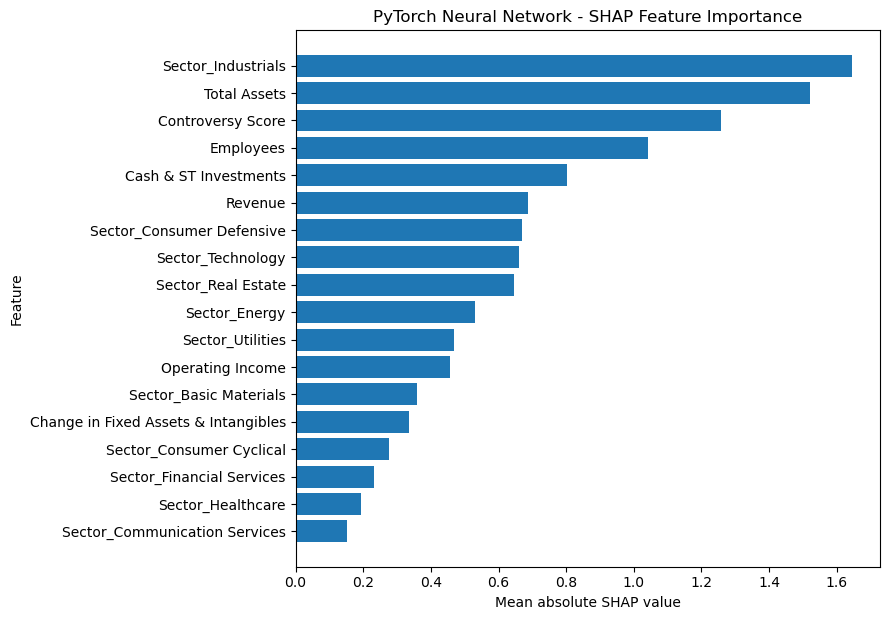

Saved image: images/pytorch_nn_shap_feature_importance.png


In [118]:
# ------------------------------------------------------------
# 8. Plot global SHAP feature importance
# ------------------------------------------------------------

top_n = min(20, len(shap_importance))

shap_plot_data = shap_importance.head(top_n).sort_values(
    by="Mean_Abs_SHAP",
    ascending=True
)

plt.figure(figsize=(9, max(5, 0.35 * top_n)))

plt.barh(
    shap_plot_data["Feature"],
    shap_plot_data["Mean_Abs_SHAP"]
)

plt.title("PyTorch Neural Network - SHAP Feature Importance")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "images/pytorch_nn_shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved image: images/pytorch_nn_shap_feature_importance.png")

# ------------------------------------------------------------

# llm via api

### Step 1

In [119]:
# ============================================================
# LLM REPORT - SELECT COMPANY FROM TEST SET
# ============================================================

print("=" * 80)
print("LLM ESG REPORT - COMPANY SELECTION")
print("=" * 80)



LLM ESG REPORT - COMPANY SELECTION


### 1. PyTorch predictions on the test set

In [120]:
# ------------------------------------------------------------
# 1. PyTorch predictions on the test set
# ------------------------------------------------------------

torch_model.eval()

with torch.no_grad():
    pytorch_test_predictions = (
        torch_model(X_test_tensor)
        .detach()
        .cpu()
        .numpy()
        .ravel()
    )



### 2. Build test company table

In [121]:
# ------------------------------------------------------------
# 2. Build test company table
# ------------------------------------------------------------

test_indices = list(X_test_model.index)

company_rows = []

for position, idx in enumerate(test_indices):
    
    row = df_clean.loc[idx]
    
    symbol = row.get("Symbol", "Unknown")
    name = row.get("Name", "Unknown")
    sector = row.get("Sector", "Unknown")
    
    actual_score = float(y_test.loc[idx])
    predicted_score = float(pytorch_test_predictions[position])
    abs_error = abs(actual_score - predicted_score)
    
    company_rows.append({
        "Test_Position": position,
        "Symbol": symbol,
        "Name": name,
        "Sector": sector,
        "Actual_ESG_Risk_Score": actual_score,
        "Predicted_ESG_Risk_Score": predicted_score,
        "Absolute_Error": abs_error
    })

test_company_table = pd.DataFrame(company_rows)

test_company_table_display = test_company_table.copy()
for col in ["Actual_ESG_Risk_Score", "Predicted_ESG_Risk_Score", "Absolute_Error"]:
    test_company_table_display[col] = test_company_table_display[col].round(3)

print("Companies available in the test set:")
display(test_company_table_display.sort_values("Symbol").reset_index(drop=True))



Companies available in the test set:


,Test_Position,Symbol,Name,Sector,Actual_ESG_Risk_Score,Predicted_ESG_Risk_Score,Absolute_Error
0,15,AAL,American Airlines Group Inc.,Industrials,26.4,25.755,0.645
1,37,ABBV,Abbvie Inc.,Healthcare,29.9,21.001,8.899
2,18,ADP,Automatic Data Processing,Industrials,13.8,22.346,8.546
3,27,AEE,Ameren Corporation,Utilities,27.2,26.379,0.821
4,8,ALLE,Allegion Public Limited Company,Industrials,21.8,21.972,0.172
...,...,...,...,...,...,...,...
71,46,URI,"United Rentals, Inc.",Industrials,16.9,20.931,4.031
72,26,V,Visa Inc.,Financial Services,16.7,19.408,2.708
73,20,WFC,Wells Fargo & Co.,Financial Services,36.2,32.217,3.983
74,28,WYNN,Wynn Resorts Ltd,Consumer Cyclical,25.7,19.480,6.220


### 3. Select company

In [122]:
# ------------------------------------------------------------
# 3. Select company
# ------------------------------------------------------------
# Option A: write a ticker that appears in the test table, e.g. "AAPL"
# Option B: leave SELECTED_SYMBOL = None and select by position

SELECTED_SYMBOL = None
SELECTED_TEST_POSITION = 0

if SELECTED_SYMBOL is not None:
    selected_matches = test_company_table[
        test_company_table["Symbol"].astype(str).str.upper() == SELECTED_SYMBOL.upper()
    ]
    
    if selected_matches.empty:
        raise ValueError(
            f"Ticker {SELECTED_SYMBOL} is not in the test set. "
            "Choose one Symbol from test_company_table_display."
        )
    
    selected_position = int(selected_matches.iloc[0]["Test_Position"])

else:
    selected_position = int(SELECTED_TEST_POSITION)

selected_idx = test_indices[selected_position]
selected_row = df_clean.loc[selected_idx]

selected_symbol = selected_row.get("Symbol", "Unknown")
selected_name = selected_row.get("Name", "Unknown")
selected_sector = selected_row.get("Sector", "Unknown")

selected_actual = float(y_test.loc[selected_idx])
selected_predicted = float(pytorch_test_predictions[selected_position])
selected_error = abs(selected_actual - selected_predicted)

print("\nSelected company:")
print("Position in test set:", selected_position)
print("Symbol:", selected_symbol)
print("Name:", selected_name)
print("Sector:", selected_sector)
print("Actual ESG Risk Score:", round(selected_actual, 3))
print("Predicted ESG Risk Score:", round(selected_predicted, 3))
print("Absolute Error:", round(selected_error, 3))


Selected company:
Position in test set: 0
Symbol: CMCSA
Name: Comcast Corp
Sector: Communication Services
Actual ESG Risk Score: 23.1
Predicted ESG Risk Score: 23.05
Absolute Error: 0.05


### Step 1

In [123]:
# ============================================================
# LLM REPORT - BUILD MODEL INTERPRETATION INPUTS
# ============================================================

print("=" * 80)
print("LLM ESG REPORT - MODEL INPUT SUMMARY")
print("=" * 80)



LLM ESG REPORT - MODEL INPUT SUMMARY


### 1. Risk bucket based on predicted score

In [124]:
# ------------------------------------------------------------
# 1. Risk bucket based on predicted score
# ------------------------------------------------------------
# Sustainalytics-style interpretation commonly uses:
# negligible/low/medium/high/severe type buckets.
# Here we use simple descriptive buckets for the report.

def esg_risk_bucket(score):
    if score < 10:
        return "Negligible ESG risk"
    elif score < 20:
        return "Low ESG risk"
    elif score < 30:
        return "Medium ESG risk"
    elif score < 40:
        return "High ESG risk"
    else:
        return "Severe ESG risk"

predicted_bucket = esg_risk_bucket(selected_predicted)
actual_bucket = esg_risk_bucket(selected_actual)

print("Predicted risk bucket:", predicted_bucket)
print("Actual risk bucket:", actual_bucket)



Predicted risk bucket: Medium ESG risk
Actual risk bucket: Medium ESG risk


### 2. Company raw variables used in the project

In [125]:
# ------------------------------------------------------------
# 2. Company raw variables used in the project
# ------------------------------------------------------------

report_variables = [
    "Sector",
    "Full Time Employees",
    "Controversy Score",
    "Revenue",
    "Operating Income (Loss)",
    "Cash, Cash Equivalents & Short Term Investments",
    "Total Assets",
    "Change in Fixed Assets & Intangibles"
]

company_data_for_report = {}

for col in report_variables:
    if col in selected_row.index:
        value = selected_row[col]
        company_data_for_report[col] = value

company_data_for_report_display = pd.DataFrame(
    list(company_data_for_report.items()),
    columns=["Variable", "Value"]
)

print("\nCompany variables used in the model:")
display(company_data_for_report_display)




Company variables used in the model:


,Variable,Value
0,Sector,Communication Services
1,Full Time Employees,"186,000"
2,Controversy Score,2.0
3,Revenue,121572000000.0
4,Operating Income (Loss),23313000000.0
5,"Cash, Cash Equivalents & Short Term Investments",6215000000.0
6,Total Assets,264811000000
7,Change in Fixed Assets & Intangibles,-15540000000.0


### 3. Global SHAP top features

In [126]:
# ------------------------------------------------------------
# 3. Global SHAP top features
# ------------------------------------------------------------

global_shap_top = shap_importance.copy().head(10)

global_shap_top_display = global_shap_top.copy()
global_shap_top_display["Mean_Abs_SHAP"] = (
    global_shap_top_display["Mean_Abs_SHAP"].round(4)
)

print("\nTop global SHAP features:")
display(global_shap_top_display)




Top global SHAP features:


,Feature,Mean_Abs_SHAP
0,Sector_Industrials,1.6454
1,Total Assets,1.5217
2,Controversy Score,1.2575
3,Employees,1.0423
4,Cash & ST Investments,0.8011
5,Revenue,0.6872
6,Sector_Consumer Defensive,0.6682
7,Sector_Technology,0.6610
8,Sector_Real Estate,0.6449
9,Sector_Energy,0.5319


### 4. Local SHAP contributions for selected company

In [127]:
# ------------------------------------------------------------
# 4. Local SHAP contributions for selected company
# ------------------------------------------------------------

selected_shap_values = shap_values[selected_position]

local_shap_table = pd.DataFrame({
    "Feature": nn_feature_names,
    "SHAP_Value": selected_shap_values
})

local_shap_table["Abs_SHAP_Value"] = local_shap_table["SHAP_Value"].abs()

local_shap_table = local_shap_table.sort_values(
    by="Abs_SHAP_Value",
    ascending=False
).reset_index(drop=True)

local_shap_table_display = local_shap_table.copy()
local_shap_table_display["SHAP_Value"] = local_shap_table_display["SHAP_Value"].round(4)
local_shap_table_display["Abs_SHAP_Value"] = local_shap_table_display["Abs_SHAP_Value"].round(4)

print("\nTop local SHAP contributions for selected company:")
display(local_shap_table_display.head(10))




Top local SHAP contributions for selected company:


,Feature,SHAP_Value,Abs_SHAP_Value
0,Total Assets,2.8098,2.8098
1,Change in Fixed Assets & Intangibles,2.4619,2.4619
2,Employees,-2.0815,2.0815
3,Sector_Technology,0.8005,0.8005
4,Sector_Communication Services,0.6036,0.6036
5,Operating Income,-0.5511,0.5511
6,Cash & ST Investments,0.4981,0.4981
7,Sector_Industrials,-0.4285,0.4285
8,Sector_Utilities,-0.3335,0.3335
9,Sector_Real Estate,0.2562,0.2562


### 5. Model performance summary for prompt

In [128]:
# ------------------------------------------------------------
# 5. Model performance summary for prompt
# ------------------------------------------------------------

best_model_row = final_comparison[
    final_comparison["Model"] == "PyTorch Neural Network"
].iloc[0]

pytorch_performance = {
    "Test RMSE": float(best_model_row["Test RMSE"]),
    "Test MAE": float(best_model_row["Test MAE"]),
    "Test R2": float(best_model_row["Test R²"])
}

print("\nPyTorch test performance:")
print(pytorch_performance)


PyTorch test performance:
{'Test RMSE': 4.915, 'Test MAE': 3.968, 'Test R2': 0.47}


### Step 1

In [129]:
# ============================================================
# LLM REPORT VIA GROQ API
# ============================================================

import os
import json
import requests
from getpass import getpass

print("=" * 80)
print("LLM ESG REPORT VIA GROQ API")
print("=" * 80)



LLM ESG REPORT VIA GROQ API


### 1. Insert API key safely

In [130]:
from getpass import getpass

GROQ_API_KEY = getpass("Inserisci la tua Groq API key: ")

### 2. Prepare prompt

In [131]:
# ------------------------------------------------------------
# 2. Prepare prompt
# ------------------------------------------------------------

company_data_text = company_data_for_report_display.to_string(index=False)

global_shap_text = global_shap_top_display.to_string(index=False)

local_shap_text = local_shap_table_display.head(10).to_string(index=False)

prompt = f"""
You are an ESG risk analyst.

Write a concise professional ESG risk report for the following company.

Important methodological constraints:
- The ESG Risk Score prediction is produced by a trained PyTorch Neural Network.
- The LLM does not predict the score.
- The LLM only explains the machine learning output in readable language.
- Interpret all model results as predictive associations, not causal effects.
- SHAP values measure feature contributions to the model prediction, not causal impacts.

Company:
- Symbol: {selected_symbol}
- Name: {selected_name}
- Sector: {selected_sector}

Model output:
- Actual ESG Risk Score: {selected_actual:.3f}
- Predicted ESG Risk Score: {selected_predicted:.3f}
- Absolute prediction error: {selected_error:.3f}
- Predicted risk bucket: {predicted_bucket}
- Actual risk bucket: {actual_bucket}

Best model performance on the held-out test set:
- Test RMSE: {pytorch_performance["Test RMSE"]:.3f}
- Test MAE: {pytorch_performance["Test MAE"]:.3f}
- Test R-squared: {pytorch_performance["Test R2"]:.3f}

Company variables used by the model:
{company_data_text}

Top global SHAP feature importance values:
{global_shap_text}

Top local SHAP contributions for this company:
{local_shap_text}

Write the report with the following structure:
1. Company and predicted ESG risk profile
2. Prediction accuracy for this company
3. Main drivers according to SHAP
4. Interpretation of financial variables, sector and controversy score
5. Limitations

Keep the tone academic and suitable for a university machine learning project.
Avoid causal language.
Do not invent external facts about the company.
"""



### 3. Call Groq Chat Completions API

In [132]:
# ------------------------------------------------------------
# 3. Call Groq Chat Completions API
# ------------------------------------------------------------

url = "https://api.groq.com/openai/v1/chat/completions"

headers = {
    "Authorization": f"Bearer {GROQ_API_KEY}",
    "Content-Type": "application/json"
}

payload = {
    "model": "llama-3.3-70b-versatile",
    "messages": [
        {
            "role": "system",
            "content": (
                "You are a careful ESG and machine learning analyst. "
                "You write clear reports based only on the data provided. "
                "You never claim causality from predictive models."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ],
    "temperature": 0.2,
    "max_tokens": 1200
}

response = requests.post(
    url,
    headers=headers,
    data=json.dumps(payload),
    timeout=60
)

if response.status_code != 200:
    print("Groq API error")
    print("Status code:", response.status_code)
    print(response.text)
    raise RuntimeError("Groq API request failed.")

response_json = response.json()

llm_report = response_json["choices"][0]["message"]["content"]

print("\n" + "=" * 80)
print("LLM-GENERATED ESG RISK REPORT")
print("=" * 80)
print(llm_report)



Groq API error
Status code: 401
{"error":{"message":"Invalid API Key","type":"invalid_request_error","code":"invalid_api_key"}}



RuntimeError: Groq API request failed.